# General Data Import and Information

Dataset URL: https://www.kaggle.com/datasets/aliafzal9323/us-domestic-airline-airfare-dataset-20082025

In [1]:
%pip install pandas numpy scipy matplotlib xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [200]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('US_DOT_Airfare_Historical_2008_2025.csv')

# Display the DataFrame
df

,year,quarter,origin_city,destination_city,distance_miles,passengers,avg_fare,largest_carrier,largest_carrier_market_share,largest_carrier_fare,lowest_fare_carrier,lowest_fare_carrier_share,lowest_fare,year_quarter,fare_per_mile
0,2008,2,"Birmingham, AL","Philadelphia, PA",772,180.43,180.16,US,0.57,188.51,DL,0.18,184.62,2008_Q2,0.23
1,2008,2,"Knoxville, TN","Miami, FL (Metropolitan Area)",724,179.89,175.70,G4,0.53,94.42,G4,0.53,94.42,2008_Q2,0.24
2,2008,2,"Omaha, NE","Tampa, FL (Metropolitan Area)",1190,179.67,164.20,AA,0.34,155.58,NW,0.16,138.78,2008_Q2,0.14
3,2008,2,"Buffalo, NY","Houston, TX",1297,179.67,234.43,WN,0.21,228.85,NW,0.13,185.28,2008_Q2,0.18
4,2008,2,"Columbus, OH","Raleigh/Durham, NC",361,179.67,165.42,AA,0.45,149.39,AA,0.45,149.39,2008_Q2,0.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68030,2025,2,"Rochester, NY","Tampa, FL (Metropolitan Area)",1079,238.79,184.18,WN,0.32,221.70,XP,0.30,84.52,2025_Q2,0.17
68031,2025,2,"Charleston, SC","Pittsburgh, PA",524,238.68,152.90,MX,0.59,96.77,MX,0.59,96.77,2025_Q2,0.29
68032,2025,2,"Fort Myers, FL","Raleigh/Durham, NC",667,238.46,145.18,MX,0.37,85.91,XP,0.23,80.75,2025_Q2,0.22
68033,2025,2,"New Orleans, LA","Portland, OR",2050,238.13,269.35,AS,0.42,273.20,DL,0.15,254.26,2025_Q2,0.13


In [201]:
# Check for missing values for each feature (There are none!)
df.isnull().sum()

year                            0
quarter                         0
origin_city                     0
destination_city                0
distance_miles                  0
passengers                      0
avg_fare                        0
largest_carrier                 0
largest_carrier_market_share    0
largest_carrier_fare            0
lowest_fare_carrier             0
lowest_fare_carrier_share       0
lowest_fare                     0
year_quarter                    0
fare_per_mile                   0
dtype: int64

In [202]:
# Display the data types for each feature
df.dtypes

year                              int64
quarter                           int64
origin_city                         str
destination_city                    str
distance_miles                    int64
passengers                      float64
avg_fare                        float64
largest_carrier                     str
largest_carrier_market_share    float64
largest_carrier_fare            float64
lowest_fare_carrier                 str
lowest_fare_carrier_share       float64
lowest_fare                     float64
year_quarter                        str
fare_per_mile                   float64
dtype: object

# Shared Pre-Processing

In [203]:
import re
import numpy as np
from scipy.stats import linregress

# =============================================================================
# SHARED PREPROCESSING
# =============================================================================

# == 1. Parse the time dimension ===============================================
# year and quarter are stored as integers with no inherent ordering relationship.
# Converting to a single datetime column enforces chronological sort order and
# provides a consistent merge key across all downstream dataframes.
# Maps each quarter to its first month: Q1->Jan, Q2->Apr, Q3->Jul, Q4->Oct.

df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' +
    ((df['quarter'] - 1) * 3 + 1).astype(str) + '-01'
)
df = df.sort_values('date').reset_index(drop=True)

# == 2. Clean and standardize city names ======================================
# Some entries include parenthetical suffixes e.g. "Miami, FL (Metropolitan Area)".
# Without removal, the same city appears under multiple string keys, silently
# corrupting any route-level groupby or aggregation.

def clean_city(name: str) -> str:
    return re.sub(r'\s*\(.*?\)', '', name).strip()

df['origin_city']      = df['origin_city'].apply(clean_city)
df['destination_city'] = df['destination_city'].apply(clean_city)

# == 3. Create a canonical route key ==========================================
# Chicago->NYC and NYC->Chicago are the same market. Sorting city names
# alphabetically before joining guarantees one consistent key per city-pair
# regardless of which city was logged as origin in a given quarter.

df['route'] = df.apply(
    lambda r: ' <-> '.join(sorted([r['origin_city'], r['destination_city']])),
    axis=1
)

# == 4. Flag externally-driven disruption periods =============================
# Both events caused sharp demand swings driven by factors outside normal
# market behavior. Flagging them serves two purposes:
#   (a) exclusion from trend classification so organic trends aren't distorted
#   (b) inclusion as learnable binary features in the forecasting models

# Financial crisis: demand declined sharply from mid-2008; recovery complete by 2010
df['is_financial_crisis'] = (
    ((df['year'] == 2008) & (df['quarter'] >= 3)) |
    (df['year'] == 2009)
).astype(int)

# Pandemic: domestic travel collapsed in 2020 Q1 and remained suppressed
# through 2021 Q3 - extended past initial lockdowns to capture the full
# period of abnormal demand before sustained recovery began
df['is_pandemic'] = (
    (df['year'] == 2020) |
    ((df['year'] == 2021) & (df['quarter'] <= 3))
).astype(int)

# Unified flag for convenience - individual flags retained for model features
df['is_external_shock'] = (
    df['is_pandemic'] | df['is_financial_crisis']
).astype(int)

# == 5. Engineer the trend label ===============================================
# For each route, fit a linear regression over non-shock quarterly passengers.
# Classification uses both slope direction and p-value:
#   p >= 0.05            -> stable (no statistically significant trend)
#   p <  0.05, slope > 0 -> emerging
#   p <  0.05, slope < 0 -> declining
#   < 8 clean quarters   -> insufficient_data
#
# 8 quarters is the minimum window to span two full seasonal cycles and
# reduce sensitivity to individual anomalous quarters. slope_pct and
# annual conversions are observational only - they do not affect classification.

def classify_trend(series, min_periods=8):
    series = series.sort_index()
    if len(series) < min_periods:
        return pd.Series({
            'trend_label': 'insufficient_data',
            'slope':        np.nan,
            'slope_pct':    np.nan,
            'p_value':      np.nan
        })
    slope, _, _, p_value, _ = linregress(range(len(series)), series)
    slope_pct = (slope / series.mean()) * 100

    if p_value > 0.05:
        label = 'stable'
    else:
        label = 'emerging' if slope > 0 else 'declining'

    return pd.Series({
        'trend_label': label,
        'slope':        round(slope, 4),
        'slope_pct':    round(slope_pct, 4),
        'p_value':      round(p_value, 4)
    })

# Compute trends on shock-excluded data - prevents crisis-driven swings
# from being mistaken for genuine long-run route behavior
route_trends_raw = (
    df[df['is_external_shock'] == 0]
    .groupby(['route', 'date'])['passengers']
    .mean()
    .reset_index()
    .groupby('route')['passengers']
    .apply(classify_trend, include_groups=False)
    .unstack()
    .reset_index()
)

route_trends_raw.columns.name   = None
route_trends_raw['slope']       = route_trends_raw['slope'].astype(float)
route_trends_raw['slope_pct']   = route_trends_raw['slope_pct'].astype(float)
route_trends_raw['p_value']     = route_trends_raw['p_value'].astype(float)

# Annual conversions for observational reporting only - multiply by 4 quarters
route_trends_raw['slope_annual']     = route_trends_raw['slope'] * 4
route_trends_raw['slope_pct_annual'] = route_trends_raw['slope_pct'] * 4

# Extract label Series and merge into df - pipeline behavior unchanged
route_trends = route_trends_raw.set_index('route')['trend_label'].rename('trend_label')
df = df.merge(route_trends, on='route', how='left')

# == 6a. Derive supporting features ===========================================
# Volatility features capture demand and pricing stability per route.
# Used as clustering features - high volatility routes tend to cluster
# together and correlate with higher model prediction error.

df['fare_volatility']      = df.groupby('route')['avg_fare'].transform('std')
df['passenger_volatility'] = df.groupby('route')['passengers'].transform('std')

# Distance band groups routes into four operationally meaningful tiers.
# Ordinal encoding is appropriate here because the categories have a
# genuine natural order - short routes are physically closer than medium ones.
df['distance_band'] = pd.cut(
    df['distance_miles'],
    bins=[0, 500, 1000, 1500, 3000],
    labels=['short', 'medium', 'long', 'ultra']
)

# == 6b. Encode distance band ==================================================
# pd.cut returns a Categorical dtype which rejects unknown fill values.
# astype(object) breaks out of Categorical before mapping and filling,
# allowing -1 as a sentinel for any out-of-range distances.

distance_order = {'short': 0, 'medium': 1, 'long': 2, 'ultra': 3}
df['distance_band_encoded'] = (
    df['distance_band']
    .astype(object)
    .map(distance_order)
    .fillna(-1)
    .astype(int)
)

## Trend Classification Summary (Observational)

This cell provides observational output for the purposes of the report and presentation only to add further context.
We categorize "Confident" and "Marginal" as the for both emerging and declining routes, respectively.

Trend Slope Summary (Observational)

EMERGING - 782 routes
  Avg slope      : +8.6991 passengers/quarter  (+34.7966 passengers/year)
  Avg slope_pct  : +1.3545% per quarter  (+5.4178% per year)
  Avg p_value    : 0.0028

DECLINING - 122 routes
  Avg slope      : -5.6156 passengers/quarter  (-22.4626 passengers/year)
  Avg slope_pct  : -1.0169% per quarter  (-4.0674% per year)
  Avg p_value    : 0.0056

STABLE - 312 routes
  Avg slope      : +1.1500 passengers/quarter  (+4.6000 passengers/year)
  Avg slope_pct  : +0.2824% per quarter  (+1.1297% per year)
  Avg p_value    : 0.3834


Top 10 Fastest Growing Routes (by annual slope_pct):
---------------------------------------------------------------------------
                                      route  slope_annual  slope_pct_annual  p_value
Martha's Vineyard, MA <-> New York City, NY        111.41             39.77     0.00
              Los Angeles, CA <-> Provo, UT        173.51             33.40     0.00
                Madison, WI 

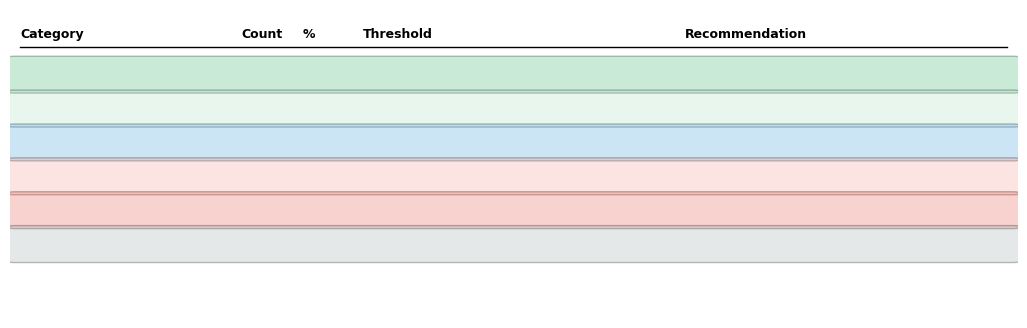

In [204]:
# =============================================================================
# TREND CLASSIFICATION SUMMARY (Observational)
# =============================================================================
# All outputs here are for reporting and interpretation purposes only.
# Nothing in this section modifies the pipeline or affects model inputs.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# == Slope summary by trend category ==========================================

print("Trend Slope Summary (Observational)")
print("=" * 75)

for label in ['emerging', 'declining', 'stable']:
    subset = route_trends_raw[route_trends_raw['trend_label'] == label]
    print(f"\n{label.upper()} - {len(subset)} routes")
    print(f"  Avg slope      : {subset['slope'].mean():+.4f} passengers/quarter  "
          f"({subset['slope_annual'].mean():+.4f} passengers/year)")
    print(f"  Avg slope_pct  : {subset['slope_pct'].mean():+.4f}% per quarter  "
          f"({subset['slope_pct_annual'].mean():+.4f}% per year)")
    print(f"  Avg p_value    : {subset['p_value'].mean():.4f}")

# Top and bottom routes by annual growth rate
print("\n\nTop 10 Fastest Growing Routes (by annual slope_pct):")
print("-" * 75)
print(
    route_trends_raw[route_trends_raw['trend_label'] == 'emerging']
    .sort_values('slope_pct_annual', ascending=False)
    [['route', 'slope_annual', 'slope_pct_annual', 'p_value']]
    .head(10)
    .to_string(index=False)
)

print("\n\nTop 10 Fastest Declining Routes (by annual slope_pct):")
print("-" * 75)
print(
    route_trends_raw[route_trends_raw['trend_label'] == 'declining']
    .sort_values('slope_pct_annual', ascending=True)
    [['route', 'slope_annual', 'slope_pct_annual', 'p_value']]
    .head(10)
    .to_string(index=False)
)

# == Empirical distribution of slope_pct_annual ===============================
# Used to derive data-driven confidence thresholds rather than hardcoding
# arbitrary values. Thresholds are set at the 25th percentile of emerging
# and 75th percentile of declining - separating strong trends from marginal ones.

print('=' * 50)
print("slope_pct_annual distribution across all classified routes:")
print(route_trends_raw[
    route_trends_raw['trend_label'] != 'insufficient_data'
]['slope_pct_annual'].describe())

print("\nEmerging routes slope_pct_annual distribution:")
print(route_trends_raw[
    route_trends_raw['trend_label'] == 'emerging'
]['slope_pct_annual'].describe())

print("\nDeclining routes slope_pct_annual distribution:")
print(route_trends_raw[
    route_trends_raw['trend_label'] == 'declining'
]['slope_pct_annual'].describe())

# == Confidence thresholds =====================================================
# Both thresholds are derived from the empirical distribution so they
# recalibrate automatically if the dataset changes.

emerging_p25  = route_trends_raw[
    route_trends_raw['trend_label'] == 'emerging'
]['slope_pct_annual'].quantile(0.25)

declining_p75 = route_trends_raw[
    route_trends_raw['trend_label'] == 'declining'
]['slope_pct_annual'].quantile(0.75)

print(f"Emerging threshold  (25th percentile): {emerging_p25:+.4f}% per year")
print(f"Declining threshold (75th percentile): {declining_p75:+.4f}% per year")

# == Confidence classification =================================================
# Adds a finer-grained label distinguishing strong trends from marginal ones.
# High-confidence routes exceed the empirical threshold - marginal routes
# are statistically significant but growing or declining slowly enough to
# warrant caution before committing to investment or discontinuation.

def classify_confidence(row):
    if row['trend_label'] == 'insufficient_data':
        return 'insufficient_data'
    elif row['trend_label'] == 'stable':
        return 'stable'
    elif row['trend_label'] == 'emerging':
        if row['slope_pct_annual'] >= emerging_p25:
            return 'high_confidence_emerging'
        else:
            return 'marginal_emerging'
    elif row['trend_label'] == 'declining':
        if row['slope_pct_annual'] <= declining_p75:
            return 'high_confidence_declining'
        else:
            return 'marginal_declining'

route_trends_raw['confidence_label'] = route_trends_raw.apply(
    classify_confidence, axis=1
)

print(f"\nConfidence label distribution:")
print(route_trends_raw['confidence_label'].value_counts())
print(f"\nTotal routes: {len(route_trends_raw)}")

# == Confidence classification table ==========================================

confidence_order = [
    'high_confidence_emerging',
    'marginal_emerging',
    'stable',
    'marginal_declining',
    'high_confidence_declining',
    'insufficient_data',
]

confidence_colors = {
    'high_confidence_emerging':  '#27ae60',
    'marginal_emerging':         '#a9dfbf',
    'stable':                    '#3498db',
    'marginal_declining':        '#f1948a',
    'high_confidence_declining': '#e74c3c',
    'insufficient_data':         '#95a5a6',
}

display_labels = {
    'high_confidence_emerging':  'High-Confidence Emerging',
    'marginal_emerging':         'Marginal Emerging',
    'stable':                    'Stable',
    'marginal_declining':        'Marginal Declining',
    'high_confidence_declining': 'High-Confidence Declining',
    'insufficient_data':         'Insufficient Data',
}

# Floor and ceiling of each band - derived from data, not hardcoded
emerging_min  = route_trends_raw[
    route_trends_raw['trend_label'] == 'emerging'
]['slope_pct_annual'].min()

declining_max = route_trends_raw[
    route_trends_raw['trend_label'] == 'declining'
]['slope_pct_annual'].max()

threshold_notes = {
    'high_confidence_emerging':  f'slope_pct_annual >= +{emerging_p25:.2f}%',
    'marginal_emerging':         f'+{emerging_min:.2f}% <= slope_pct_annual < +{emerging_p25:.2f}%',
    'stable':                    'p >= 0.05 (no significant trend)',
    'marginal_declining':        f'{declining_p75:.2f}% < slope_pct_annual <= {declining_max:.2f}%',
    'high_confidence_declining': f'slope_pct_annual <= {declining_p75:.2f}%',
    'insufficient_data':         '< 8 non-shock quarters available',
}

recommendations_map = {
    'high_confidence_emerging':  'Prioritize capacity investment',
    'marginal_emerging':         'Monitor - invest cautiously',
    'stable':                    'Maintain current capacity',
    'marginal_declining':        'Monitor - defer cuts',
    'high_confidence_declining': 'Review for discontinuation',
    'insufficient_data':         'Defer major decisions',
}

counts = route_trends_raw['confidence_label'].value_counts()
total  = len(route_trends_raw)

# == Print table ===============================================================

print("Route Confidence Classification Summary")
print("=" * 105)
print(f"  Emerging threshold  (25th percentile): +{emerging_p25:.4f}% per year")
print(f"  Declining threshold (75th percentile):  {declining_p75:.4f}% per year")
print("=" * 105)
print(f"{'Category':<30} {'Count':>6} {'%':>6}  {'Threshold':<45} {'Recommendation'}")
print("-" * 105)
for label in confidence_order:
    count = counts.get(label, 0)
    pct   = count / total * 100
    print(
        f"{display_labels[label]:<30} "
        f"{count:>6,} "
        f"{pct:>5.1f}%  "
        f"{threshold_notes[label]:<45} "
        f"{recommendations_map[label]}"
    )
print("=" * 105)

# == Visualization =============================================================

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

col_headers = ['Category', 'Count', '%', 'Threshold', 'Recommendation']
col_widths  = [0.22, 0.06, 0.06, 0.32, 0.28]
col_starts  = [0.01]
for w in col_widths[:-1]:
    col_starts.append(col_starts[-1] + w)

row_h   = 0.11
start_y = 0.88

for j, (header, x) in enumerate(zip(col_headers, col_starts)):
    ax.text(x, start_y + 0.04, header,
            transform=ax.transAxes,
            fontsize=9, fontweight='bold', va='center')

ax.axhline(start_y, color='black', linewidth=1, xmin=0.01, xmax=0.99)

for i, label in enumerate(confidence_order):
    y         = start_y - (i + 1) * row_h
    count     = counts.get(label, 0)
    pct       = count / total * 100
    row_color = confidence_colors[label]

    ax.add_patch(mpatches.FancyBboxPatch(
        (0.005, y - 0.03), 0.99, row_h - 0.01,
        boxstyle="round,pad=0.01",
        facecolor=row_color,
        alpha=0.25,
        transform=ax.transAxes
    ))

    row_data

In [205]:
# Before any model-specific pre-processing, we create a copy of the original dataframe specifically to be used for clustering
df_clustering = df.copy()

# Model-Specific Pre-Processing

In [206]:
# ==============================================================================
# SUPERVISED REGRESSION - Route-level time series
# ==============================================================================

# Aggregate to one passenger observation per route per quarter.
# This is the fundamental unit of analysis for all three forecasting models.
# The `ts` suffix denotes time series.

route_ts = (
    df.groupby(['route', 'date'])['passengers']
    .mean()
    .reset_index()
    .sort_values(['route', 'date'])
    .reset_index(drop=True)
)

# Lag features encode temporal structure explicitly since tree-based models
# have no inherent sense of time. NaNs arise on the first observations of
# each route and are handled at modeling time via dropna.
#   passengers_lag1 - short-term momentum signal
#   passengers_lag4 - same quarter last year; captures annual seasonality
#   rolling_mean_4  - smoothed baseline; min_periods=1 prevents NaNs here

route_ts['passengers_lag1'] = route_ts.groupby('route')['passengers'].shift(1)
route_ts['passengers_lag4'] = route_ts.groupby('route')['passengers'].shift(4)
route_ts['rolling_mean_4']  = (
    route_ts.groupby('route')['passengers']
    .transform(lambda x: x.rolling(4, min_periods=1).mean())
)

# Ordinal label encoding for tree-based models - acceptable here because
# tree splits on thresholds rather than interpreting numeric distance
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['trend_label_encoded'] = le.fit_transform(df['trend_label'].astype(str))

# ==============================================================================
# K-MEANS CLUSTERING - Route-level summary features
# ==============================================================================

# K-Means operates on one vector per route rather than quarterly observations.
# Aggregating to route level collapses the time series into summary statistics
# that characterize each route's overall behavior across its full history.

route_features = df_clustering.groupby('route').agg(
    avg_passengers        = ('passengers',            'mean'),
    passenger_volatility  = ('passenger_volatility',  'first'),
    avg_fare              = ('avg_fare',               'mean'),
    fare_volatility       = ('fare_volatility',        'first'),
    distance_miles        = ('distance_miles',         'first'),
    distance_band_encoded = ('distance_band_encoded',  'first'),
    trend_label           = ('trend_label',            'first'),
).reset_index()

# One-hot encode trend labels for clustering - K-Means uses Euclidean distance,
# so ordinal encoding would impose a false numeric ordering on unordered
# categories, biasing cluster assignments toward spurious groupings
trend_dummies  = pd.get_dummies(route_features['trend_label'], prefix='trend')
route_features = pd.concat([route_features, trend_dummies], axis=1)

# ==============================================================================
# PREPROCESSING COMPLETE
# ==============================================================================

print("Preprocessing complete.")
print(f"  df shape:             {df.shape}")
print(f"  df_clustering shape:  {df_clustering.shape}")
print(f"  route_ts shape:       {route_ts.shape}")
print(f"  route_features shape: {route_features.shape}")

def print_trend_dist(label, series):
    counts   = series.value_counts()
    pcts     = series.value_counts(normalize=True) * 100
    combined = pd.concat([counts, pcts], axis=1)
    combined.columns = ['count', '%']
    combined['%']    = combined['%'].map('{:.1f}%'.format)
    print(f"\nTrend label distribution for `{label}`:\n{combined.to_string()}")

print_trend_dist('df', df['trend_label'])
print_trend_dist('df_clustering', df_clustering['trend_label'])

Preprocessing complete.
  df shape:             (68035, 26)
  df_clustering shape:  (68035, 25)
  route_ts shape:       (68035, 6)
  route_features shape: (1626, 12)

Trend label distribution for `df`:
                   count      %
trend_label                    
emerging           44991  66.4%
stable             14400  21.2%
declining           7115  10.5%
insufficient_data   1291   1.9%

Trend label distribution for `df_clustering`:
                   count      %
trend_label                    
emerging           44991  66.4%
stable             14400  21.2%
declining           7115  10.5%
insufficient_data   1291   1.9%


The one column difference is between the two dataframes occurs because `df` has `trend_label_encoded` (added in 1c) while `df_clustering` doesn't. That's intentional and correct given our separation strategy.

# Exploratory Data Analysis

## Macro Trend Overview

We plot an aggregate passenger volume and average fare over time across all routes. This provides a visual narrative of the entire dataset:
- The 2008 dip + the steady recovery
- The COVID cliff + the post-pandemic rebound.

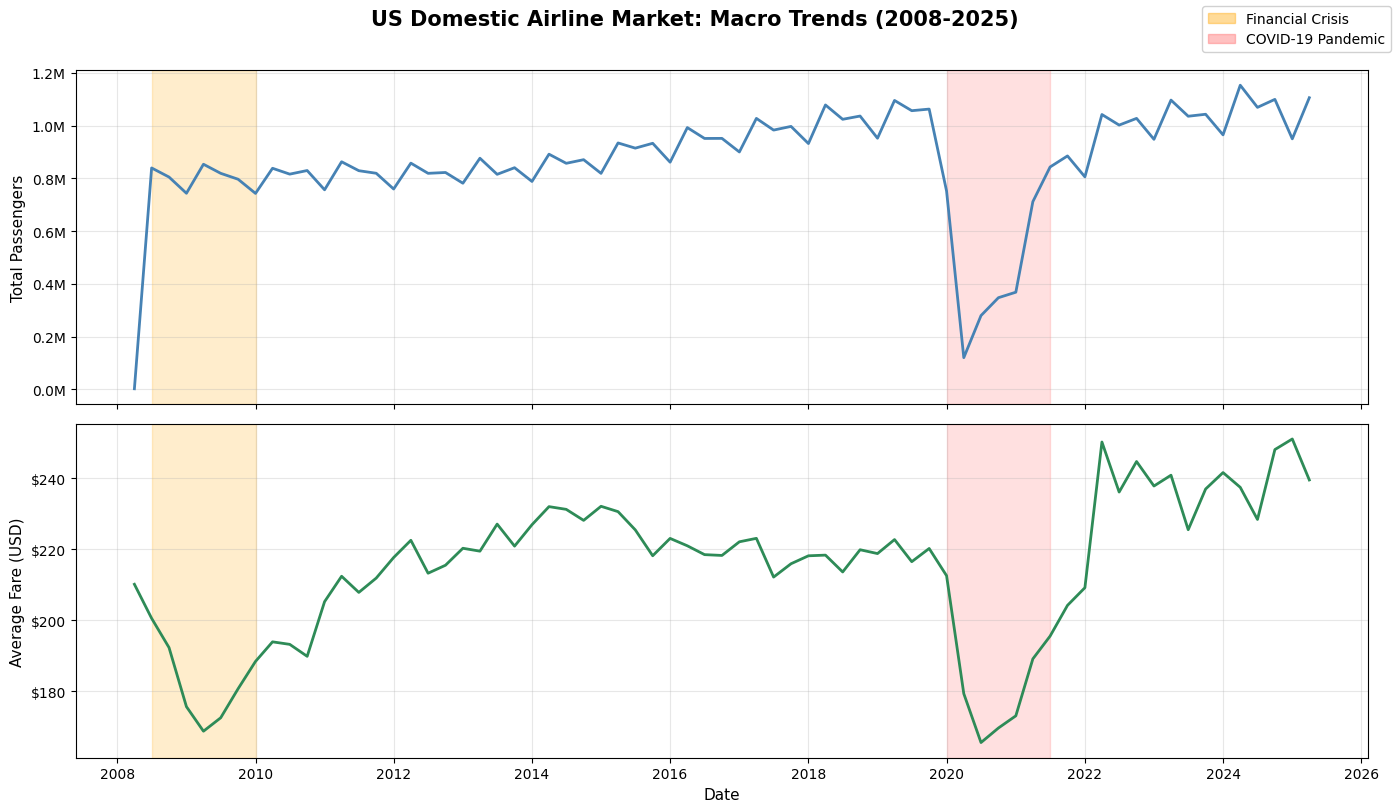

In [207]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Aggregate by quarter
macro = df.groupby('date').agg(
    total_passengers=('passengers', 'sum'),
    avg_fare=('avg_fare', 'mean')
).reset_index()

# Shock period boundaries for shading
shock_periods = [
    ('2008-07-01', '2010-01-01', 'Financial Crisis', '#FFA500'),
    ('2020-01-01', '2021-07-01', 'COVID-19 Pandemic', '#FF6666'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('US Domestic Airline Market: Macro Trends (2008-2025)', 
            fontsize=15, fontweight='bold', y=1.01)

# --- Plot 1: Total Passengers ---
ax1.plot(macro['date'], macro['total_passengers'], 
        color='steelblue', linewidth=2, label='Total Passengers')
ax1.set_ylabel('Total Passengers', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')) # type: ignore
ax1.grid(True, alpha=0.3)

# --- Plot 2: Average Fare ---
ax2.plot(macro['date'], macro['avg_fare'], 
        color='seagreen', linewidth=2, label='Avg Fare')
ax2.set_ylabel('Average Fare (USD)', fontsize=11)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}')) # type: ignore
ax2.set_xlabel('Date', fontsize=11)
ax2.grid(True, alpha=0.3)

# --- Shade shock periods on both axes ---
legend_patches = []
for start, end, label, color in shock_periods:
    for ax in [ax1, ax2]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), 
                alpha=0.2, color=color, zorder=0)
    legend_patches.append(mpatches.Patch(color=color, alpha=0.4, label=label))

# --- Shared legend ---
fig.legend(handles=legend_patches, loc='upper right', 
        fontsize=10, framealpha=0.9)

plt.tight_layout()
# plt.savefig('macro_trend_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Distribution of Trend Labels

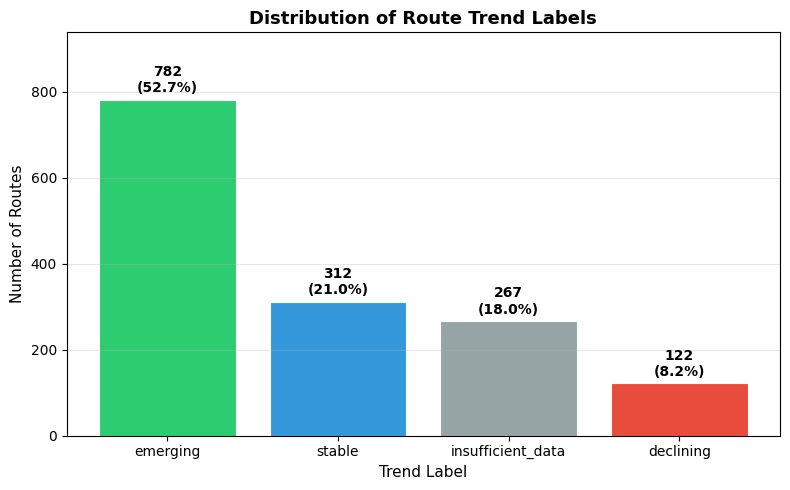

Class Balance Summary
emerging               782  (52.7%)
stable                 312  (21.0%)
insufficient_data      267  (18.0%)
declining              122  (8.2%)


In [208]:
# Aggregate to one row per route (trend label is route-level, not row-level)
route_profiles = df.dropna(subset=['trend_label']).groupby('route').agg(
    trend_label=('trend_label', 'first'),
    avg_passengers=('passengers', 'mean'),
    avg_fare=('avg_fare', 'mean'),
    distance_miles=('distance_miles', 'first')
).reset_index()

label_counts = route_profiles['trend_label'].value_counts()
label_pcts = route_profiles['trend_label'].value_counts(normalize=True) * 100

# --- Plot ---
colors = {'emerging': '#2ecc71', 'stable': '#3498db', 'declining': '#e74c3c',
        'insufficient_data': '#95a5a6'}
bar_colors = [colors[label] for label in label_counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(label_counts.index, label_counts.values, color=bar_colors,  # type: ignore
            edgecolor='white', linewidth=0.8)

# Annotate each bar with count and percentage
for bar, (label, pct) in zip(bars, label_pcts.items()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{label_counts[label]:,}\n({pct:.1f}%)', # type: ignore
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribution of Route Trend Labels', fontsize=13, fontweight='bold')
ax.set_xlabel('Trend Label', fontsize=11)
ax.set_ylabel('Number of Routes', fontsize=11)
ax.set_ylim(0, label_counts.max() * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('trend_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print class balance summary ---
print("Class Balance Summary")
print("=" * 35)
for label in label_counts.index:
    print(f"{label:<20} {label_counts[label]:>5,}  ({label_pcts[label]:.1f}%)")

## Route-Level Passenger Trends

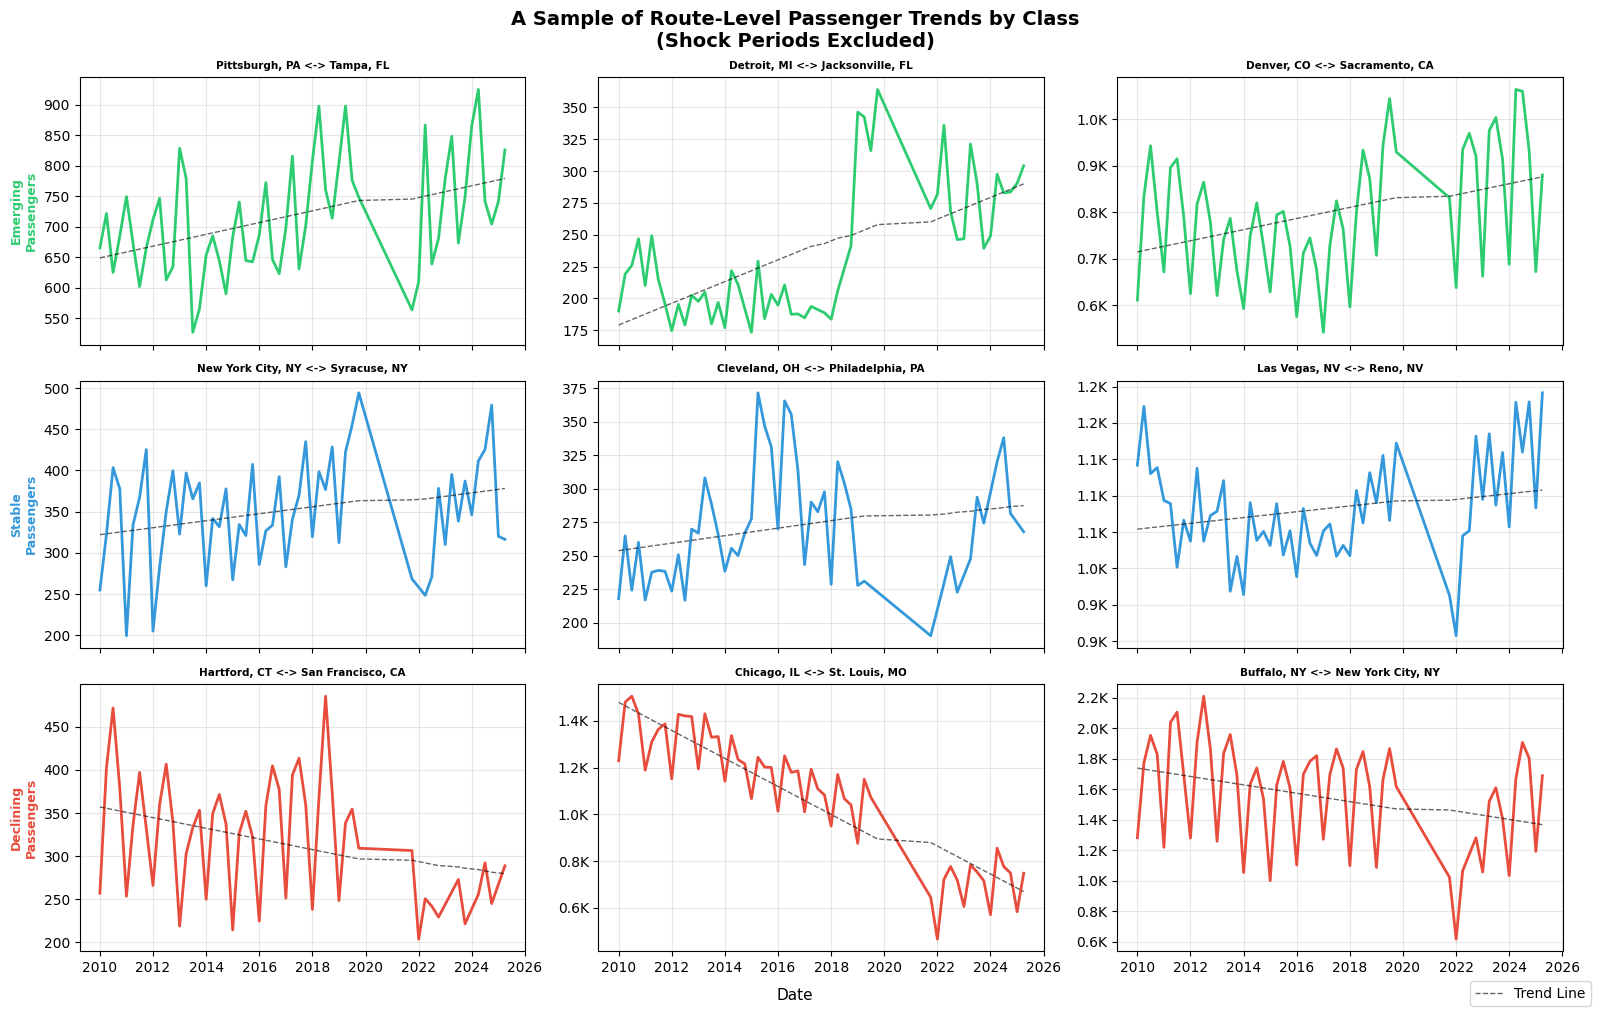

In [209]:
import random

# Filter out insufficient_data routes and shock periods
clean_routes = df[(df['is_external_shock'] == 0) & 
                (df['trend_label'] != 'insufficient_data')]

# Sample routes from each trend class
random.seed(30)  # Good Seeds: 1, 9, 16 | BEST SEED: 30, Selected to produce routes with full 2008-2025 date coverage
sample_routes = {
    label: random.sample(
        list(clean_routes[clean_routes['trend_label'] == label]['route'].unique()), 3
    )
    for label in ['emerging', 'stable', 'declining']
}

# Color mapping per trend class
trend_colors = {
    'emerging': '#2ecc71',
    'stable': '#3498db', 
    'declining': '#e74c3c'
}

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
fig.suptitle('A Sample of Route-Level Passenger Trends by Class\n(Shock Periods Excluded)', 
            fontsize=14, fontweight='bold')

for row_idx, label in enumerate(['emerging', 'stable', 'declining']):
    for col_idx, route in enumerate(sample_routes[label]):
        ax = axes[row_idx][col_idx]
        
        route_data = clean_routes[clean_routes['route'] == route].sort_values('date')
        
        ax.plot(route_data['date'], route_data['passengers'],
                color=trend_colors[label], linewidth=2)
        
        # Trend line overlay
        x_numeric = np.arange(len(route_data))
        slope, intercept, _, _, _ = linregress(x_numeric, route_data['passengers'])
        ax.plot(route_data['date'], intercept + slope * x_numeric, # type: ignore
                color='black', linewidth=1, linestyle='--', alpha=0.6, label='Trend')
        
        # Formatting
        ax.set_title(route, fontsize=7.5, fontweight='bold')
        
        y_max = route_data['passengers'].max()
        if y_max >= 10000:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')) # type: ignore
        elif y_max >= 1000:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K')) # type: ignore
        else:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}')) # type: ignore
        
        ax.grid(True, alpha=0.3)
        
        # Row label on leftmost column only
        if col_idx == 0:
            ax.set_ylabel(f'{label.capitalize()}\nPassengers', 
                        fontsize=9, color=trend_colors[label], fontweight='bold')

# Shared x-label
fig.text(0.5, -0.01, 'Date', ha='center', fontsize=11)

# Shared legend for trend line
trend_line = plt.Line2D([0], [0], color='black', linewidth=1,  # type: ignore
                        linestyle='--', alpha=0.6, label='Trend Line')
fig.legend(handles=[trend_line], loc='lower right', fontsize=10)

plt.tight_layout()
# plt.savefig('route_passenger_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Supervised Regression Forecasting Models (Linear Regression, XGBoost, Random Forest)

In [210]:
# The print statements below confirm that the lag features are intact and display exactly how many NaN rows we're dealing with from the shifting operation.

print(route_ts.columns.tolist())
print(route_ts.shape)
print(route_ts.isnull().sum())

['route', 'date', 'passengers', 'passengers_lag1', 'passengers_lag4', 'rolling_mean_4']
(68035, 6)
route                 0
date                  0
passengers            0
passengers_lag1    1626
passengers_lag4    5926
rolling_mean_4        0
dtype: int64


Here's what the NaN counts tell us:

- **`passengers_lag1`: 1,626 NaNs** - exactly one per route (the first observation of each route has no previous quarter to look back at; i.e. Q1 2008). This is expected.
- **`passengers_lag4`: 5,926 NaNs** - roughly the first four observations per route (1,626 routes × ~3-4 quarters; i.e. most or all all of 2008). This is expected.
- **`rolling_mean_4`: 0 NaNs** - clean because we used `min_periods=1`, so it computes even with partial windows.

These NaNs are handled by simply dropping them before training - we don't impute lag features because filling them with estimates would introduce false signal into the model's most important features.

In [211]:
# Merge fare from df then lag it
route_ts = route_ts.merge(
    df[['route', 'date', 'avg_fare']],
    on=['route', 'date'],
    how='left'
)
route_ts['avg_fare_lag1'] = route_ts.groupby('route')['avg_fare'].shift(1)
route_ts = route_ts.drop(columns=['avg_fare'])  # drop current-quarter fare

In [212]:
"""
Supervised Regression Pipeline - Passenger Demand Forecasting
=============================================================
Assumes the following are already in memory from preprocessing:
    route_ts   - route-level time series with lag features
    df         - full preprocessed dataframe
    le         - fitted LabelEncoder from preprocessing

Pipeline order:
    [A] Shared Setup
    [B] Linear Regression (baseline)
    [C] XGBoost
    [D] Random Forest
    [E] 3-Way Model Comparison
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# [A] SHARED SETUP
# =============================================================================

# == Configuration =============================================================

TRAIN_CUTOFF = '2022-12-01'

FEATURES = [
    'passengers_lag1',
    'passengers_lag4',
    'avg_fare_lag1',
    'rolling_mean_4',
    'year',
    'quarter',
    'distance_miles',
    'distance_band_encoded',
    'largest_carrier_market_share',
    'is_external_shock',
    'is_pandemic',
    'is_financial_crisis',
    'trend_label_encoded',
]

TARGET = 'passengers'

SAMPLE_ROUTES = {
    'emerging': [
        'Miami, FL <-> New York City, NY',
        'Los Angeles, CA <-> New York City, NY',
    ],
    'declining': [
        'Los Angeles, CA <-> San Francisco, CA',
        'Boston, MA <-> Washington, DC',
    ],
    'stable': [
        'Chicago, IL <-> New York City, NY',
        'San Diego, CA <-> San Francisco, CA',
    ]
}

COLORS = {
    'emerging':  '#2ecc71',
    'declining': '#e74c3c',
    'stable':    '#3498db',
}

# == Build modeling dataframe ==================================================

def build_model_df(route_ts: pd.DataFrame, df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge route_ts with required columns from df, engineer avg_fare_lag1,
    and drop rows with NaN in any feature or target column.
    Current-quarter fare is excluded to prevent data leakage - it is
    co-determined with passenger demand within the same period and would
    not be available at true prediction time.
    """
    df_cols = df[[
        'route', 'date',
        'avg_fare',
        'distance_miles',
        'distance_band_encoded',
        'largest_carrier_market_share',
        'is_external_shock',
        'is_pandemic',
        'is_financial_crisis',
        'trend_label_encoded',
    ]].drop_duplicates(subset=['route', 'date'])

    model_df = route_ts.merge(df_cols, on=['route', 'date'], how='left')

    # Re-derive year and quarter from date to avoid column collision on merge
    model_df['year']    = model_df['date'].dt.year
    model_df['quarter'] = model_df['date'].dt.quarter

    model_df = model_df.sort_values(['route', 'date']).reset_index(drop=True)

    # Lag fare by one quarter - legitimate proxy available at prediction time
    model_df['avg_fare_lag1'] = (
        model_df.groupby('route')['avg_fare'].shift(1)
    )
    model_df = model_df.drop(columns=['avg_fare'])

    required_cols = FEATURES + [TARGET]
    model_df = model_df.dropna(subset=required_cols).reset_index(drop=True)

    print(f"Model dataframe shape after cleaning: {model_df.shape}")
    print(f"NaN check:\n{model_df[required_cols].isnull().sum()}")
    return model_df


# == Temporal leakage correction ===============================================

def compute_train_only_trend_labels(model_df: pd.DataFrame) -> pd.DataFrame:
    """
    Recompute trend labels using only pre-cutoff training data to prevent
    look-ahead bias. The original trend labels used the full dataset history
    including test-period data, which a model deployed in 2022 would not
    have access to. The resulting MAPE increase of less than 1% confirms
    leakage was present but not severely distorting results.
    """
    train_only = model_df[model_df['date'] <= TRAIN_CUTOFF]

    def classify_trend(series, min_periods=8):
        series = series.sort_index()
        if len(series) < min_periods:
            return 'insufficient_data'
        slope, _, _, p_value, _ = linregress(range(len(series)), series)
        if p_value > 0.05:
            return 'stable'
        return 'emerging' if slope > 0 else 'declining'

    train_labels = (
        train_only
        .groupby('route')['passengers']
        .apply(classify_trend)
        .rename('trend_label_train')
        .reset_index()
    )

    label_order = {'declining': 0, 'emerging': 1,
                   'insufficient_data': 2, 'stable': 3}
    train_labels['trend_label_encoded'] = (
        train_labels['trend_label_train'].map(label_order).fillna(2).astype(int)
    )

    model_df = model_df.drop(columns=['trend_label_encoded'])
    model_df = model_df.merge(
        train_labels[['route', 'trend_label_encoded']],
        on='route', how='left'
    )

    original = df.groupby('route')['trend_label_encoded'].first().reset_index()
    compare  = original.merge(
        train_labels[['route', 'trend_label_encoded']],
        on='route', suffixes=('_original', '_train')
    )
    changed = (
        compare['trend_label_encoded_original'] !=
        compare['trend_label_encoded_train']
    ).sum()
    print(f"Routes whose trend label changed after train-only "
          f"recomputation: {changed} / {len(compare)}")

    return model_df


# == Train/test split ==========================================================

def split_data(model_df: pd.DataFrame):
    """
    Temporal train/test split at TRAIN_CUTOFF.
    Train: 2009 Q3 - 2022 Q4
    Test:  2023 Q1 - 2025 Q2
    Ensures models are evaluated on data they have never seen,
    preventing look-ahead bias in performance estimation.
    """
    train = model_df[model_df['date'] <= TRAIN_CUTOFF]
    test  = model_df[model_df['date'] >  TRAIN_CUTOFF]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test  = test[FEATURES]
    y_test  = test[TARGET]

    print(f"\nTrain size: {len(train):,} rows  "
          f"({train['date'].min().date()} -> {train['date'].max().date()})")
    print(f"Test size:  {len(test):,} rows  "
          f"({test['date'].min().date()} -> {test['date'].max().date()})")

    return X_train, X_test, y_train, y_test, test


# == Shared evaluation helper ==================================================

def evaluate_model(model_name, preds, y_test, test_df):
    """
    Compute global RMSE and MAPE, then break down MAPE by trend label.
    Used consistently across all three models for direct comparability.
    """
    rmse = np.sqrt(np.mean((y_test.values - preds) ** 2))
    mape = mean_absolute_percentage_error(y_test, preds) * 100

    print(f"\nGlobal Evaluation - {model_name}")
    print("=" * 40)
    print(f"  RMSE : {rmse:,.1f}")
    print(f"  MAPE : {mape:.1f}%")

    test_eval = test_df.copy()
    test_eval['predicted']   = preds
    test_eval['abs_pct_err'] = (
        np.abs(test_eval[TARGET] - test_eval['predicted']) /
        test_eval[TARGET] * 100
    )

    label_map = {i: label for i, label in enumerate(le.classes_)}
    test_eval['trend_label'] = test_eval['trend_label_encoded'].map(label_map)

    print("\nMAPE by Trend Label:")
    print("-" * 40)
    breakdown = (
        test_eval.groupby('trend_label')['abs_pct_err']
        .mean()
        .sort_values()
    )
    for label, val in breakdown.items():
        print(f"  {label:<20} {val:.1f}%")

    return rmse, mape, test_eval


# == Shared route forecast plot helper ========================================

def plot_route_forecasts(model_name, model_df, preds_full, color_suffix=''):
    """
    For each sample route, plot actuals vs predicted over the full timeline
    with the train/test boundary marked. Used by all three models.
    """
    plot_df = model_df.copy()
    plot_df['predicted'] = preds_full

    for trend_label, routes in SAMPLE_ROUTES.items():
        color = COLORS[trend_label]

        for route in routes:
            route_data = plot_df[plot_df['route'] == route].sort_values('date')
            if route_data.empty:
                print(f"WARNING: No data for '{route}'. Skipping.")
                continue

            train_data = route_data[route_data['date'] <= TRAIN_CUTOFF]
            test_data  = route_data[route_data['date'] >  TRAIN_CUTOFF]

            if not test_data.empty:
                route_mape = mean_absolute_percentage_error(
                    test_data[TARGET], test_data['predicted']
                ) * 100
                route_rmse = np.sqrt(np.mean(
                    (test_data[TARGET].values -
                     test_data['predicted'].values) ** 2
                ))
            else:
                route_mape = route_rmse = None

            fig, ax = plt.subplots(figsize=(12, 4))

            ax.plot(route_data['date'], route_data[TARGET],
                    color='grey', linewidth=1.5, label='Actuals', zorder=3)
            ax.plot(train_data['date'], train_data['predicted'],
                    color=color, linewidth=2, linestyle='--',
                    label='Predicted (train)', alpha=0.8)
            if not test_data.empty:
                ax.plot(test_data['date'], test_data['predicted'],
                        color=color, linewidth=2.5,
                        label='Predicted (test)', zorder=4)
            ax.axvline(pd.Timestamp(TRAIN_CUTOFF), color='black',
                       linestyle='--', linewidth=1, alpha=0.6,
                       label='Train/test split')
            if route_mape is not None:
                ax.annotate(
                    f"RMSE: {route_rmse:,.1f}  |  MAPE: {route_mape:.1f}%",
                    xy=(0.02, 0.95), xycoords='axes fraction',
                    fontsize=9, va='top',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7)
                )

            ax.set_title(
                f"[{trend_label.capitalize()}]  {route}  |  {model_name}",
                fontsize=12, fontweight='bold'
            )
            ax.set_xlabel('Date')
            ax.set_ylabel('Avg Daily Passengers')
            ax.legend(fontsize=8, loc='upper left')
            ax.grid(alpha=0.25)
            plt.tight_layout()

            prefix = model_name.lower().replace(' ', '_')
            fname  = route.replace(' ', '_').replace('/', '-').replace('<->', 'to')
            # plt.savefig(f'{prefix}_{fname}.png', dpi=150, bbox_inches='tight')
            plt.show()


# == Run shared setup ==========================================================

model_df                  = build_model_df(route_ts, df)
model_df                  = compute_train_only_trend_labels(model_df)
X_train, X_test, y_train, y_test, test_df = split_data(model_df)

Model dataframe shape after cleaning: (62109, 16)
NaN check:
passengers_lag1                 0
passengers_lag4                 0
avg_fare_lag1                   0
rolling_mean_4                  0
year                            0
quarter                         0
distance_miles                  0
distance_band_encoded           0
largest_carrier_market_share    0
is_external_shock               0
is_pandemic                     0
is_financial_crisis             0
trend_label_encoded             0
passengers                      0
dtype: int64
Routes whose trend label changed after train-only recomputation: 656 / 1318

Train size: 52,245 rows  (2009-07-01 -> 2022-10-01)
Test size:  9,864 rows  (2023-01-01 -> 2025-04-01)


Linear Regression model trained successfully.

Global Evaluation - Linear Regression
  RMSE : 238.1
  MAPE : 16.2%

MAPE by Trend Label:
----------------------------------------
  emerging             14.6%
  declining            15.5%
  stable               17.1%
  insufficient_data    19.6%


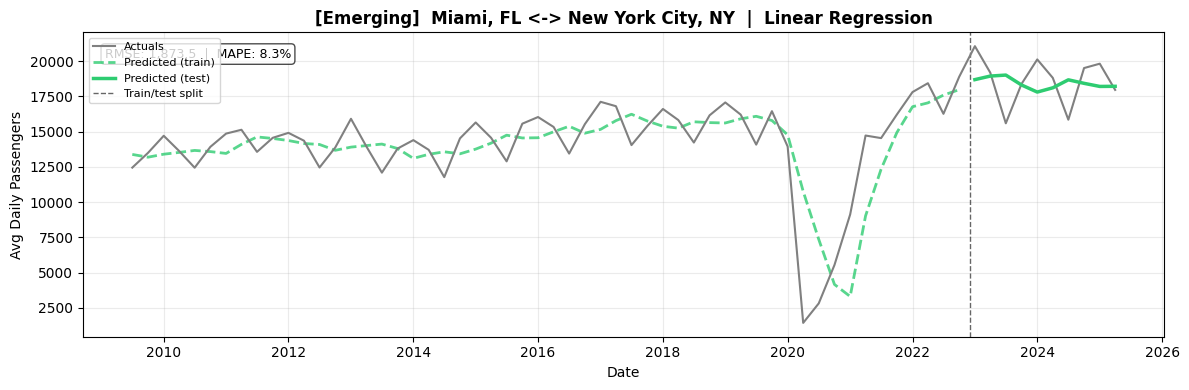

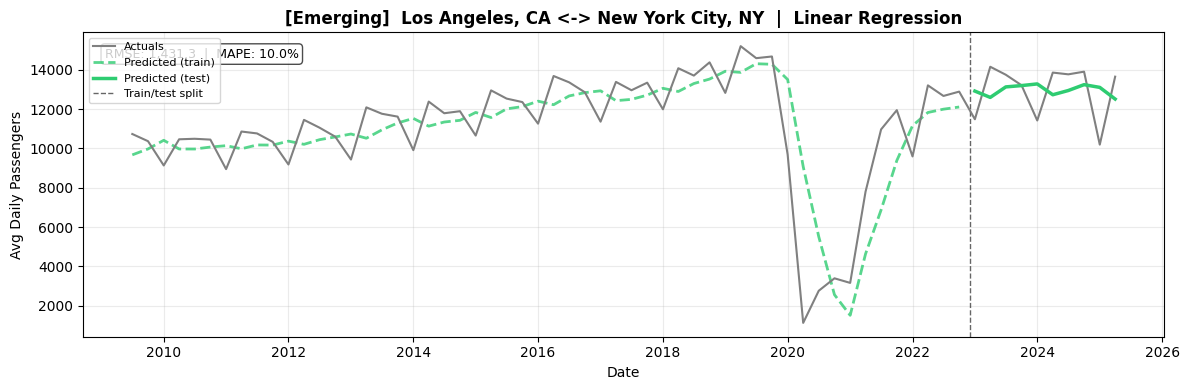

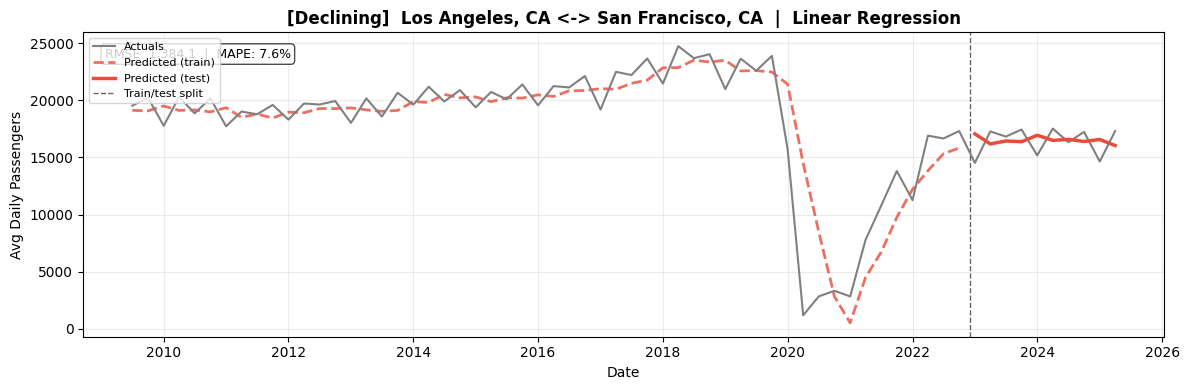

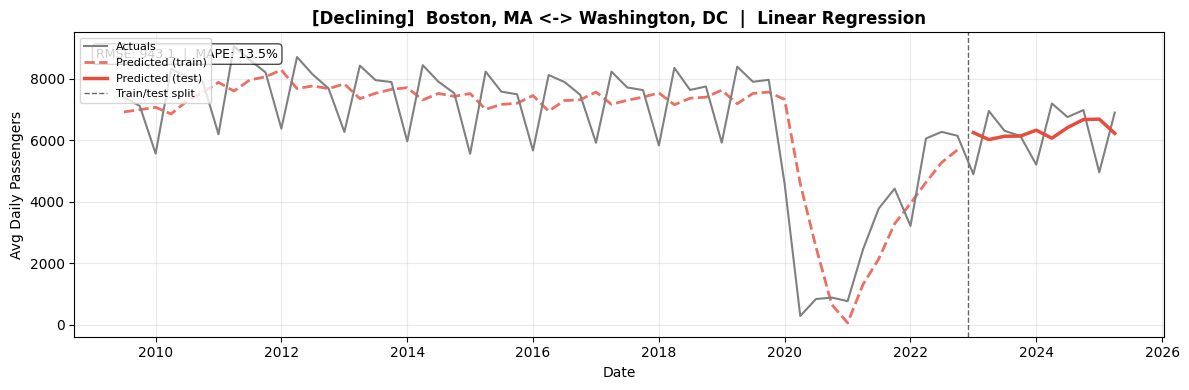

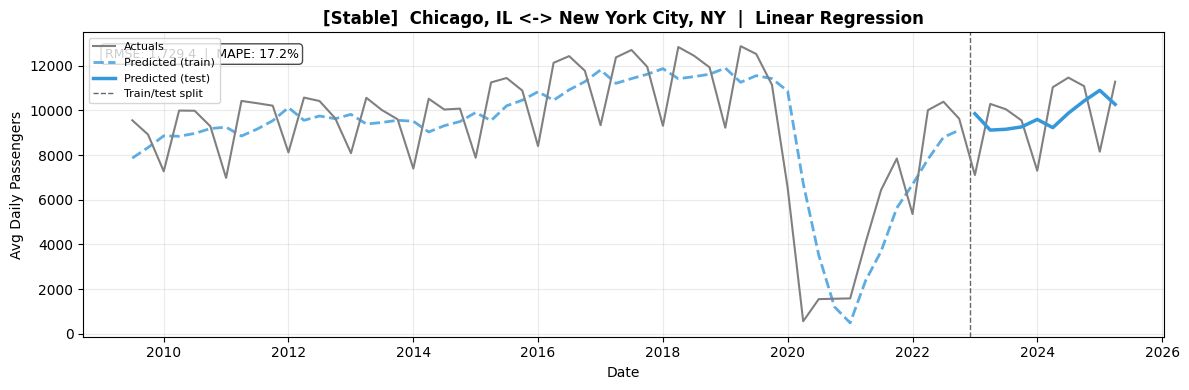

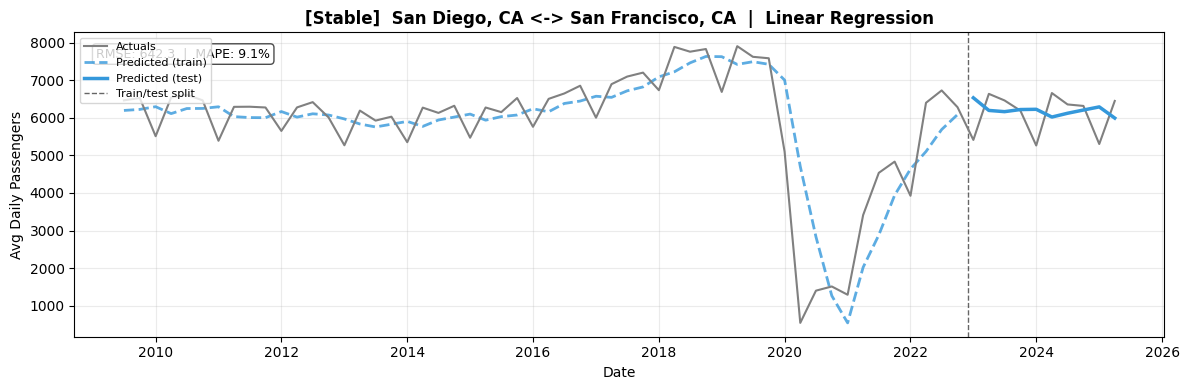

In [213]:
# =============================================================================
# [B] LINEAR REGRESSION (Baseline)
# =============================================================================
# Linear Regression models passenger demand as a weighted linear combination
# of input features. It is included as an interpretable performance baseline -
# its results establish a lower bound against which the non-linear models are
# compared, directly quantifying the value added by more complex approaches.
#
# Unlike tree-based models, Linear Regression is sensitive to feature scale.
# All input features are standardized to zero mean and unit variance prior
# to training. This transformation is applied only here - XGBoost and Random
# Forest are scale-invariant by construction.

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Handle NaNs - Linear Regression does not accept missing values natively
train_mask     = ~np.isnan(X_train_scaled).any(axis=1)
test_mask      = ~np.isnan(X_test_scaled).any(axis=1)

X_train_scaled = X_train_scaled[train_mask]
y_train_lr     = y_train.values[train_mask]
X_test_scaled  = X_test_scaled[test_mask]
y_test_lr      = y_test.values[test_mask]
test_df_lr     = test_df[test_mask].reset_index(drop=True)

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_lr)
print("Linear Regression model trained successfully.")

# Evaluate
lr_preds = lr_model.predict(X_test_scaled)

# Clip physically impossible negative predictions before evaluation
lr_preds = np.clip(lr_preds, 0, None)

lr_rmse, lr_mape, lr_test_eval = evaluate_model(
    'Linear Regression', lr_preds, pd.Series(y_test_lr), test_df_lr
)

# Route forecast plots
full_scaled_lr  = scaler.transform(model_df[FEATURES].fillna(0))
full_preds_lr   = np.clip(lr_model.predict(full_scaled_lr), 0, None)
plot_route_forecasts('Linear Regression', model_df, full_preds_lr)


XGBoost model trained successfully.

Global Evaluation - XGBoost
  RMSE : 249.4
  MAPE : 13.5%

MAPE by Trend Label:
----------------------------------------
  insufficient_data    12.5%
  emerging             13.3%
  declining            13.6%
  stable               13.7%


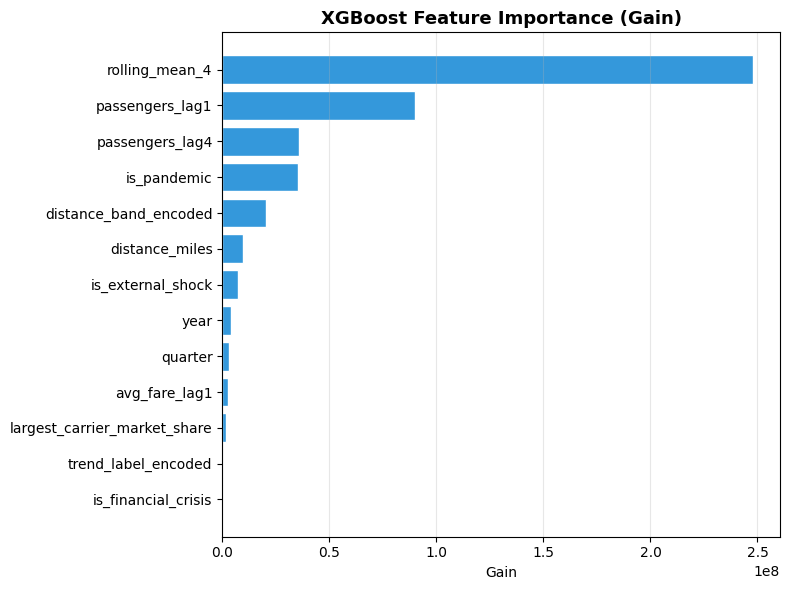

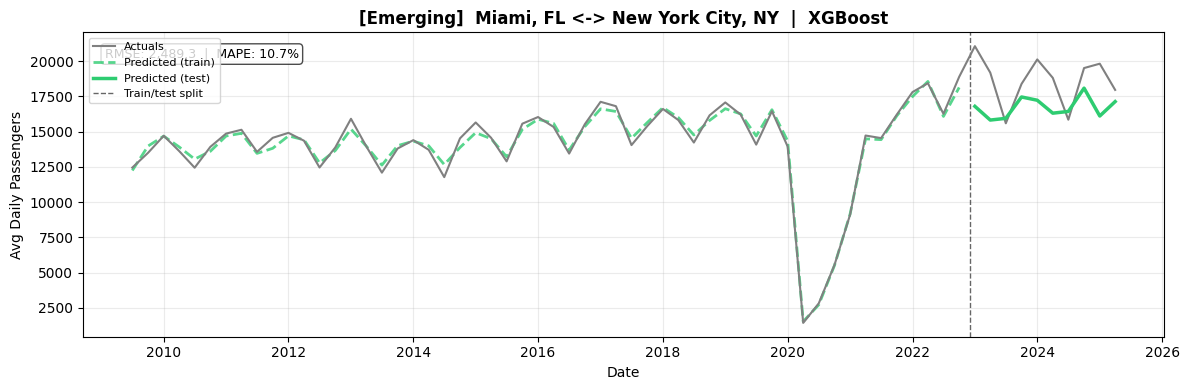

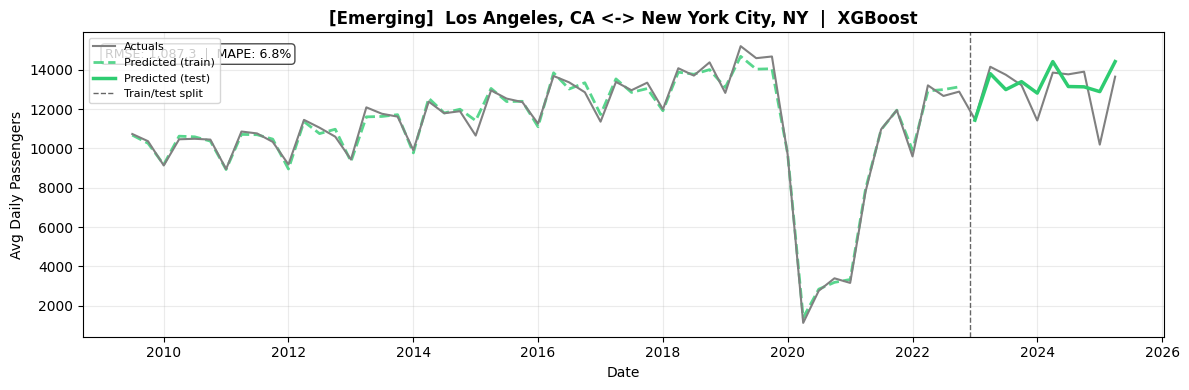

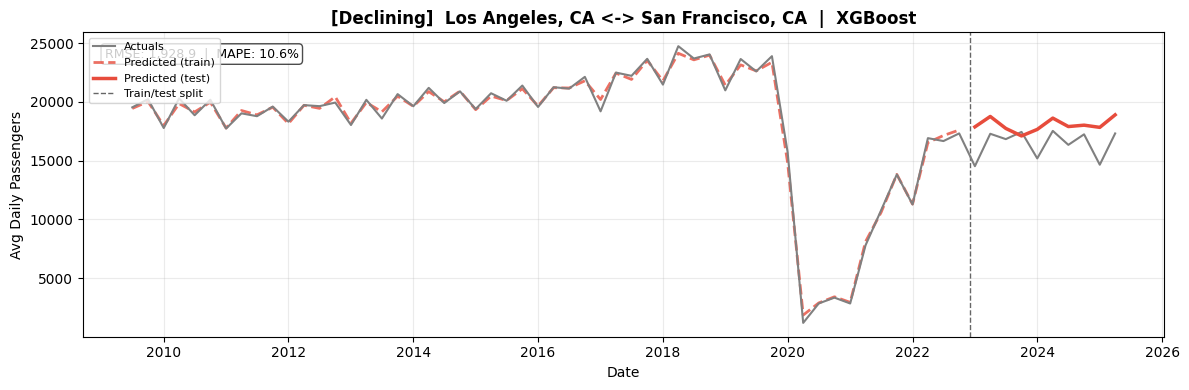

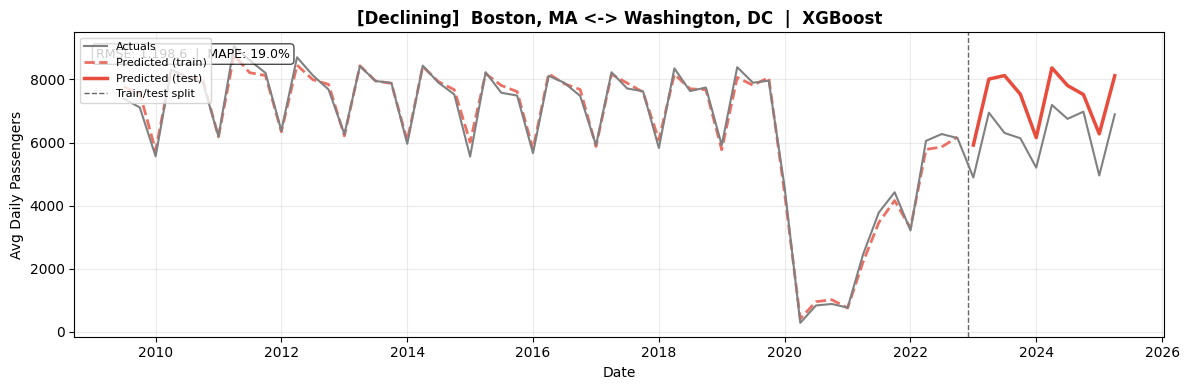

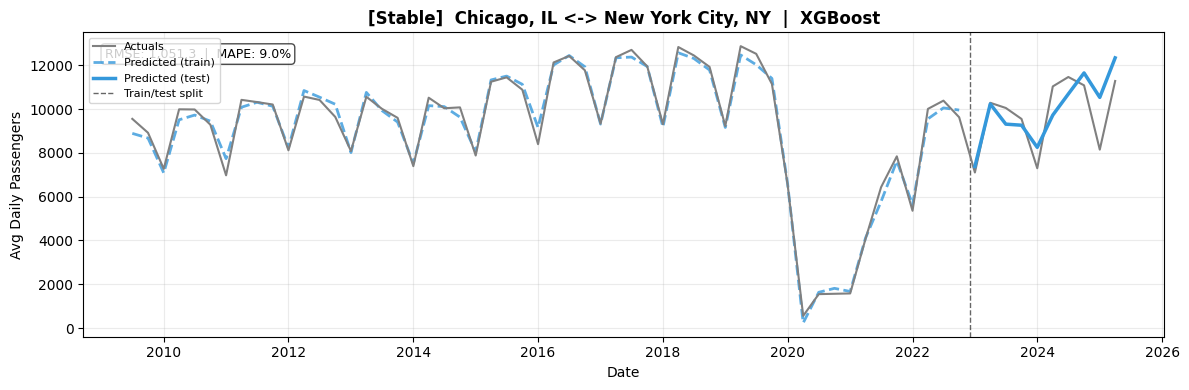

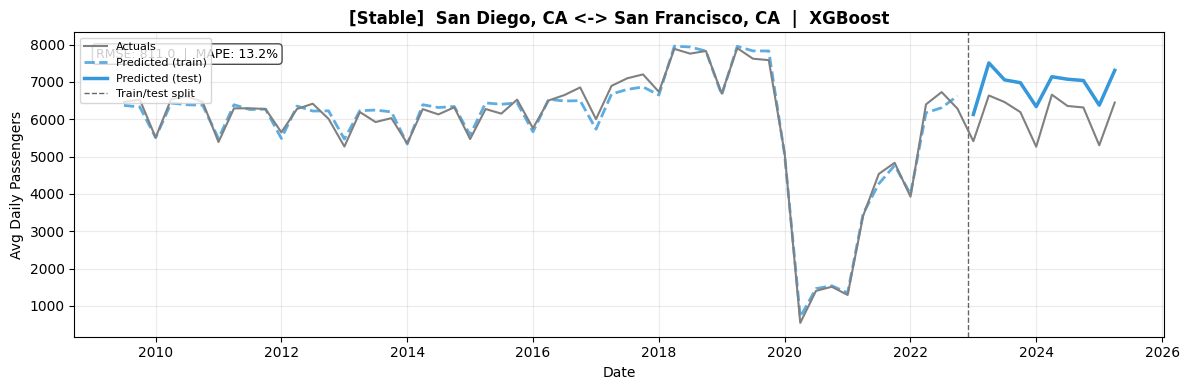

In [214]:
# =============================================================================
# [C] XGBOOST
# =============================================================================
# XGBoost is a gradient boosting ensemble that constructs a sequence of
# decision trees, each correcting the residual errors of its predecessors.
# This sequential error-correction mechanism captures complex non-linear
# relationships and feature interactions that Linear Regression cannot model.

xgb_model = xgb.XGBRegressor(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
)
xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

# Evaluate
xgb_preds = xgb_model.predict(X_test)
xgb_rmse, xgb_mape, xgb_test_eval = evaluate_model(
    'XGBoost', xgb_preds, y_test, test_df
)

# Feature importance - Gain

# Gain measures average improvement per split - natural importance metric
# for sequential boosting where each tree corrects predecessor errors
importance     = xgb_model.get_booster().get_score(importance_type='gain')
importance_df  = (
    pd.DataFrame.from_dict(importance, orient='index', columns=['gain'])
    .sort_values('gain', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df.index, importance_df['gain'],
        color='#3498db', edgecolor='white')
ax.set_title('XGBoost Feature Importance (Gain)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Gain')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
# plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Route forecast plots
xgb_full_preds = xgb_model.predict(model_df[FEATURES])
plot_route_forecasts('XGBoost', model_df, xgb_full_preds)


Random Forest model trained successfully.

Global Evaluation - Random Forest
  RMSE : 202.1
  MAPE : 11.6%

MAPE by Trend Label:
----------------------------------------
  declining            10.9%
  emerging             11.1%
  insufficient_data    11.6%
  stable               12.0%


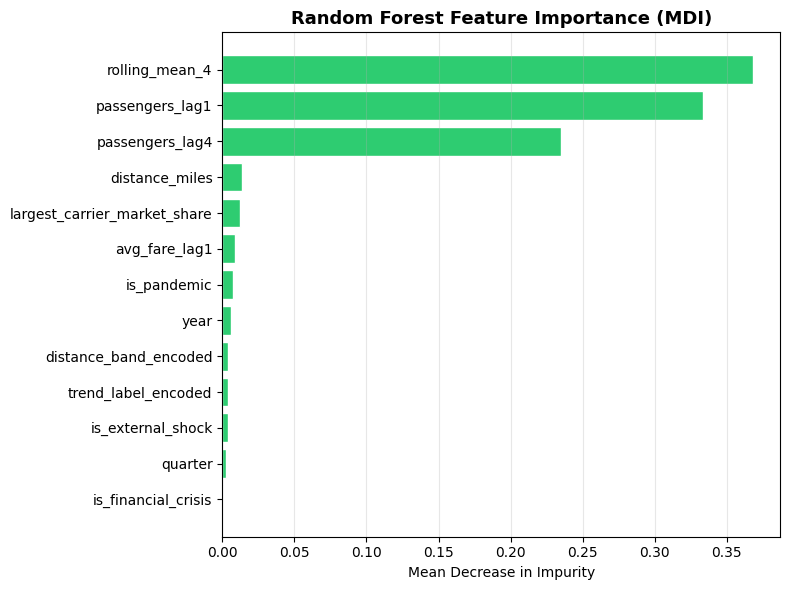

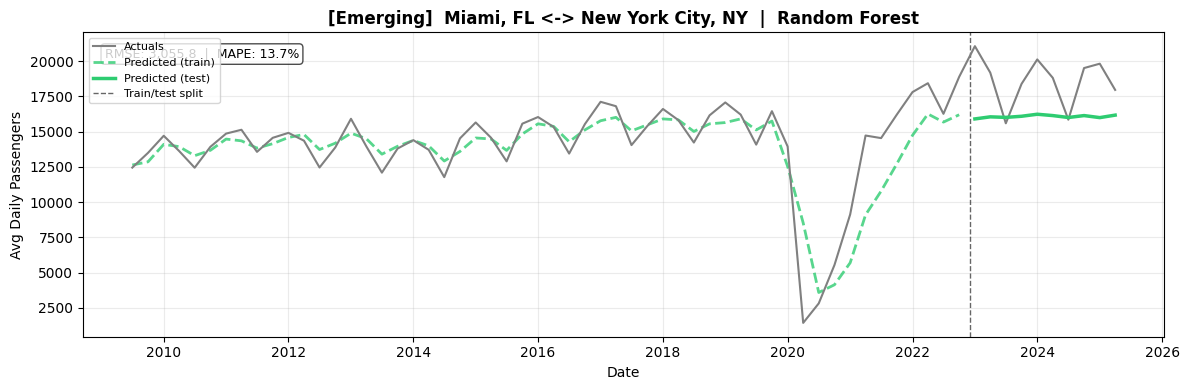

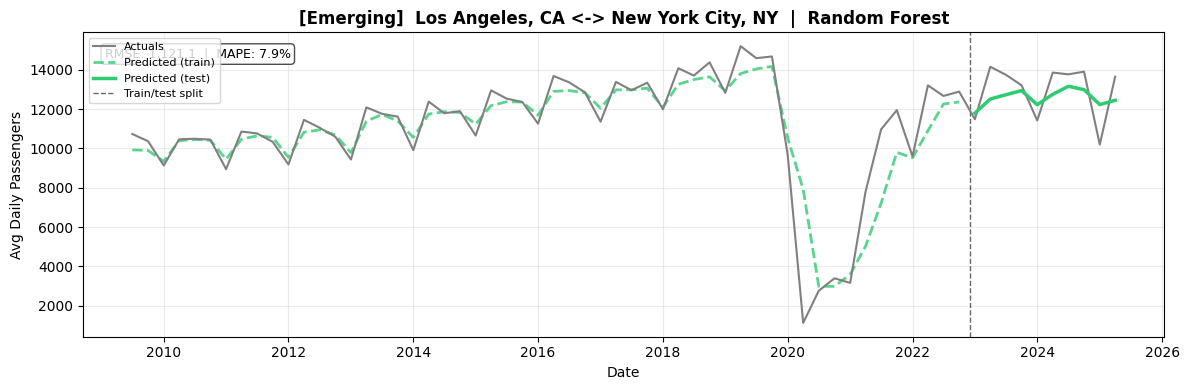

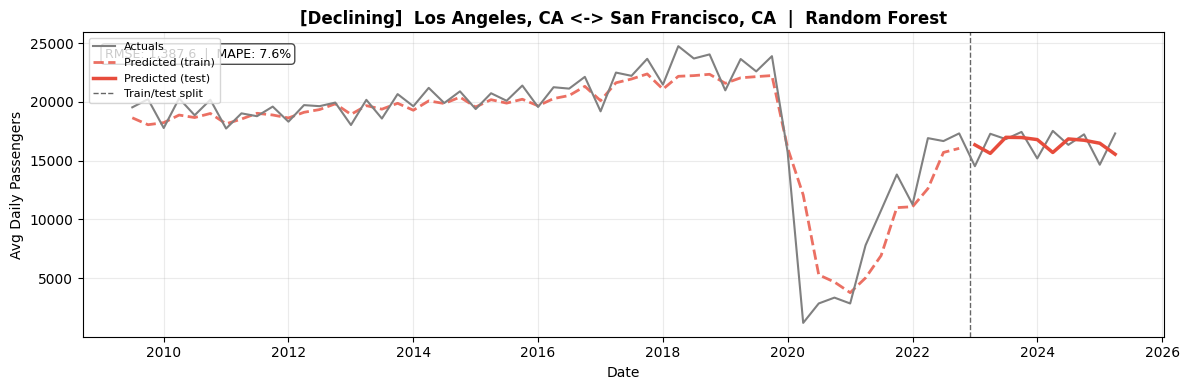

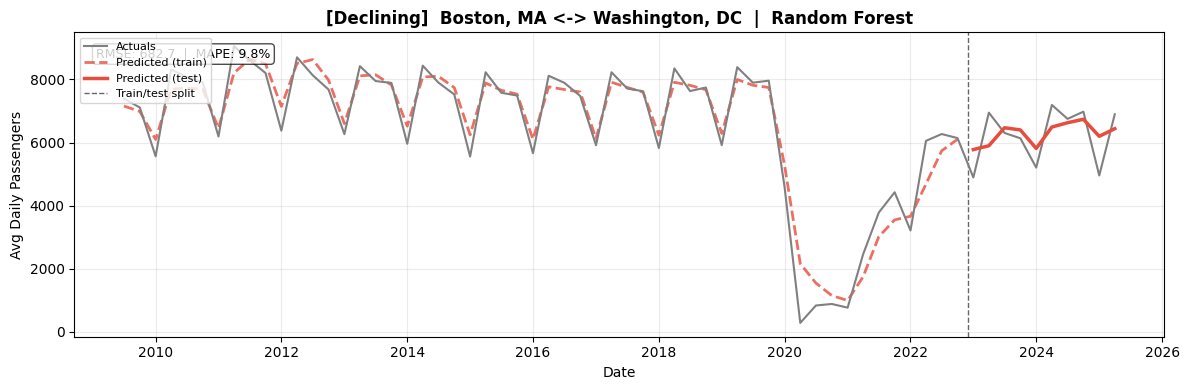

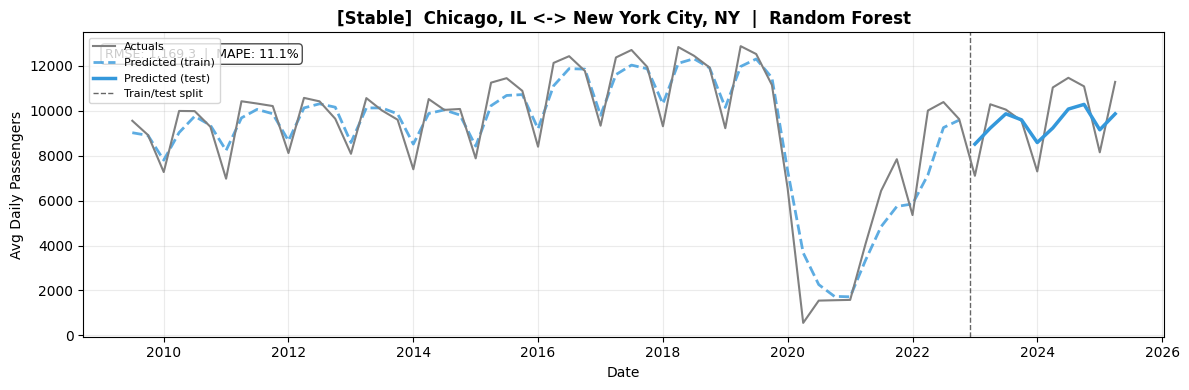

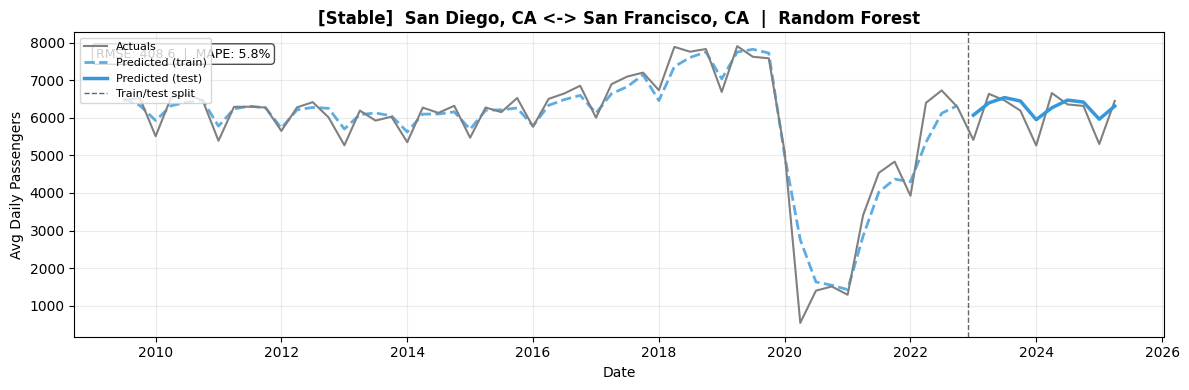

In [215]:
# =============================================================================
# [D] RANDOM FOREST
# =============================================================================
# Random Forest is a bagging ensemble that constructs trees independently
# and in parallel, averaging their predictions. Each tree is trained on a
# bootstrap sample with a random feature subset at each split, decorrelating
# the trees and reducing variance in the final ensemble prediction.
# Feature importance is measured using Mean Decrease in Impurity (MDI).

# Bootstrap sample + random feature subset decorrelates trees, reducing variance
rf_model = RandomForestRegressor(
    n_estimators     = 500,
    max_depth        = 10,
    min_samples_leaf = 5,
    max_features     = 'sqrt',
    random_state     = 42,
    n_jobs           = -1,
)
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

# Evaluate
rf_preds = rf_model.predict(X_test)
rf_rmse, rf_mape, rf_test_eval = evaluate_model(
    'Random Forest', rf_preds, y_test, test_df
)

# Feature importance - MDI

# MDI measures average variance reduction per split across all trees -
# natural importance metric for independently constructed ensembles
rf_importance_df = (
    pd.DataFrame({
        'feature':    FEATURES,
        'importance': rf_model.feature_importances_
    })
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(rf_importance_df['feature'], rf_importance_df['importance'],
        color='#2ecc71', edgecolor='white')
ax.set_title('Random Forest Feature Importance (MDI)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
# plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Route forecast plots
rf_full_preds = rf_model.predict(model_df[FEATURES])
plot_route_forecasts('Random Forest', model_df, rf_full_preds)

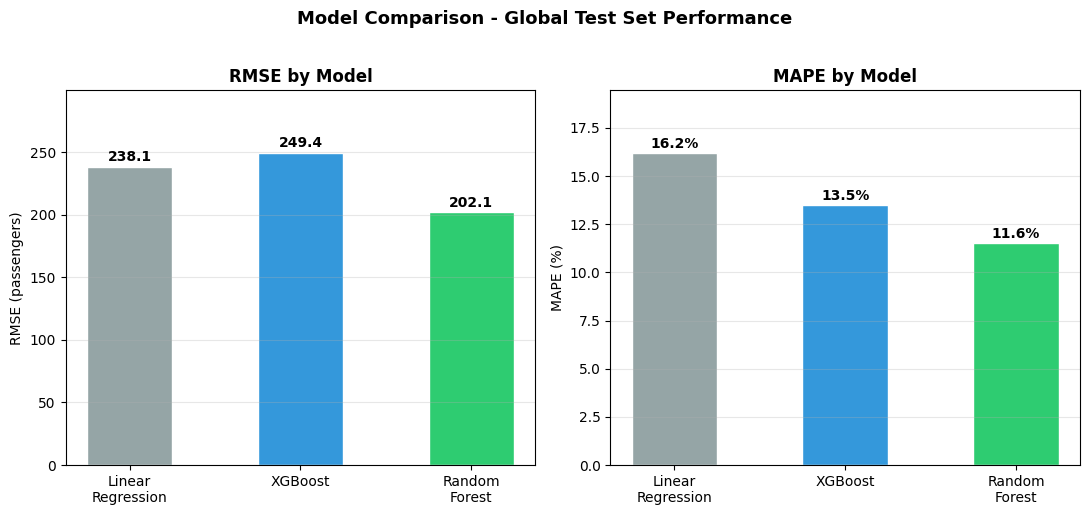


Model Comparison - Global Test Set Performance
Metric       Linear Reg      XGBoost   Random Forest
---------------------------------------------------------
RMSE              238.1        249.4           202.1
MAPE              16.2%        13.5%           11.6%

  Best RMSE : Random Forest
  Best MAPE : Random Forest

  RMSE improvement over Linear Regression baseline : 15.1%
  MAPE improvement over Linear Regression baseline : 28.7%


In [216]:
# =============================================================================
# [E] 3-WAY MODEL COMPARISON
# =============================================================================

models     = ['Linear\nRegression', 'XGBoost', 'Random\nForest']
rmse_vals  = [lr_rmse, xgb_rmse, rf_rmse]
mape_vals  = [lr_mape, xgb_mape, rf_mape]
bar_colors = ['#95a5a6', '#3498db', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

bars1 = ax1.bar(models, rmse_vals, color=bar_colors,
                edgecolor='white', width=0.5)
for bar, val in zip(bars1, rmse_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 2,
             f'{val:,.1f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax1.set_title('RMSE by Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE (passengers)')
ax1.set_ylim(0, max(rmse_vals) * 1.2)
ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(models, mape_vals, color=bar_colors,
                edgecolor='white', width=0.5)
for bar, val in zip(bars2, mape_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')
ax2.set_title('MAPE by Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('MAPE (%)')
ax2.set_ylim(0, max(mape_vals) * 1.2)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison - Global Test Set Performance',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nModel Comparison - Global Test Set Performance")
print("=" * 57)
print(f"{'Metric':<10} {'Linear Reg':>12} {'XGBoost':>12} {'Random Forest':>15}")
print("-" * 57)
print(f"{'RMSE':<10} {lr_rmse:>12,.1f} {xgb_rmse:>12,.1f} {rf_rmse:>15,.1f}")
print(f"{'MAPE':<10} {lr_mape:>11.1f}% {xgb_mape:>11.1f}% {rf_mape:>14.1f}%")
print("=" * 57)

best_rmse    = min(lr_rmse, xgb_rmse, rf_rmse)
best_mape    = min(lr_mape, xgb_mape, rf_mape)
winner_rmse  = ['Linear Regression', 'XGBoost', 'Random Forest'][
    [lr_rmse, xgb_rmse, rf_rmse].index(best_rmse)]
winner_mape  = ['Linear Regression', 'XGBoost', 'Random Forest'][
    [lr_mape, xgb_mape, rf_mape].index(best_mape)]
print(f"\n  Best RMSE : {winner_rmse}")
print(f"  Best MAPE : {winner_mape}")

rmse_improvement = (lr_rmse - best_rmse) / lr_rmse * 100
mape_improvement = (lr_mape - best_mape) / lr_mape * 100
print(f"\n  RMSE improvement over Linear Regression baseline : "
      f"{rmse_improvement:.1f}%")
print(f"  MAPE improvement over Linear Regression baseline : "
      f"{mape_improvement:.1f}%")

## Saving Test Predictions

In [217]:
# =============================================================================
# SAVE TEST PREDICTIONS
# =============================================================================
# Stores per-row predictions and absolute percentage errors from all three
# models alongside route metadata. The route-level summary (route_model_errors)
# is passed into K-Means clustering as xgb_mape and rf_mape features,
# connecting forecasting difficulty to route structural characteristics.
#
# Variable reference:
#   lr_preds  - Linear Regression predictions (aligned via test_df_lr)
#   xgb_preds - XGBoost predictions (aligned with test_df)
#   rf_preds  - Random Forest predictions (aligned with test_df)

predictions_df = test_df[['route', 'date', 'passengers',
                           'trend_label_encoded']].copy()

# Linear Regression test set may have fewer rows than test_df due to NaN
# dropping during scaling - merge on route + date rather than assuming
# positional alignment
lr_pred_df = test_df_lr[['route', 'date']].copy()
lr_pred_df['lr_predicted'] = lr_preds
predictions_df = predictions_df.merge(lr_pred_df, on=['route', 'date'], how='left')

# XGBoost and Random Forest were trained on the full test_df - direct assignment
predictions_df['xgb_predicted'] = xgb_preds
predictions_df['rf_predicted']  = rf_preds

# Absolute percentage error per row - model-agnostic error metric that
# normalizes prediction error relative to actual passenger volume,
# making routes of different sizes directly comparable
predictions_df['xgb_ape'] = (
    np.abs(predictions_df['passengers'] - predictions_df['xgb_predicted']) /
    predictions_df['passengers'] * 100
)
predictions_df['rf_ape'] = (
    np.abs(predictions_df['passengers'] - predictions_df['rf_predicted']) /
    predictions_df['passengers'] * 100
)
predictions_df['lr_ape'] = (
    np.abs(predictions_df['passengers'] - predictions_df['lr_predicted']) /
    predictions_df['passengers'] * 100
)

# Collapse to one row per route - average APE across test quarters produces
# a route-level MAPE used as a clustering feature in K-Means
route_model_errors = (
    predictions_df.groupby('route').agg(
        xgb_mape            = ('xgb_ape',             'mean'),
        rf_mape             = ('rf_ape',              'mean'),
        lr_mape             = ('lr_ape',              'mean'),
        trend_label_encoded = ('trend_label_encoded', 'first')
    ).reset_index()
)

# fillna(2) assigns insufficient_data encoding to any routes missing a label
route_model_errors['trend_label_encoded'] = (
    route_model_errors['trend_label_encoded'].fillna(2).astype(int)
)

print(f"predictions_df shape:     {predictions_df.shape}")
print(f"route_model_errors shape: {route_model_errors.shape}")
print(f"\nSample:")
print(route_model_errors.head(10).to_string(index=False))

predictions_df shape:     (9864, 10)
route_model_errors shape: (1165, 5)

Sample:
                          route  xgb_mape  rf_mape  lr_mape  trend_label_encoded
     Albany, NY <-> Atlanta, GA     10.49    12.42    20.65                    3
     Albany, NY <-> Chicago, IL     16.67    16.53    22.67                    3
      Albany, NY <-> Denver, CO      4.51    11.66    17.90                    3
 Albany, NY <-> Los Angeles, CA      4.20     8.47    10.38                    3
       Albany, NY <-> Miami, FL     14.10    12.17    20.81                    3
     Albany, NY <-> Orlando, FL      9.76     8.79    12.84                    3
       Albany, NY <-> Tampa, FL     12.73    12.37    23.34                    3
  Albany, NY <-> Washington, DC     11.58    11.05    17.29                    0
Albuquerque, NM <-> Atlanta, GA      8.53     5.38     8.46                    1
 Albuquerque, NM <-> Austin, TX      6.33     6.46    12.83                    1


# K-Means Clustering

In [218]:
## Viewing the state of `route_features`

print(route_features.columns.tolist())
print(route_features.shape)
print(route_features.isnull().sum())

['route', 'avg_passengers', 'passenger_volatility', 'avg_fare', 'fare_volatility', 'distance_miles', 'distance_band_encoded', 'trend_label', 'trend_declining', 'trend_emerging', 'trend_insufficient_data', 'trend_stable']
(1626, 12)
route                        0
avg_passengers               0
passenger_volatility       125
avg_fare                     0
fare_volatility            125
distance_miles               0
distance_band_encoded        0
trend_label                143
trend_declining              0
trend_emerging               0
trend_insufficient_data      0
trend_stable                 0
dtype: int64


**125 NaNs in `passenger_volatility` and `fare_volatility`** - these are routes that appear only once in the dataset, so standard deviation is undefined for a single observation. We'll drop these rows since a route with only one quarter of data isn't meaningful for clustering.

**143 NaNs in `trend_label`** - these are routes that didn't get a label assigned, likely because they fell entirely within shock periods. We'll drop these too.

**`route_model_errors` needs to be merged in** - this adds per-model MAPE columns which will allow us to examine whether prediction difficulty clusters together.

In [219]:
# Check how many routes survive after merging with route_model_errors
merged_check = route_features.merge(route_model_errors[['route', 'xgb_mape', 
                                    'rf_mape', 'lr_mape']], 
                                    on='route', how='inner')
print(f"Routes surviving inner merge: {merged_check.shape[0]}")
# This tells us how many routes have both clustering features AND model error data before we commit to the pipeline design.

Routes surviving inner merge: 1165


Clustering dataframe: 1165 routes (0 dropped due to NaNs)


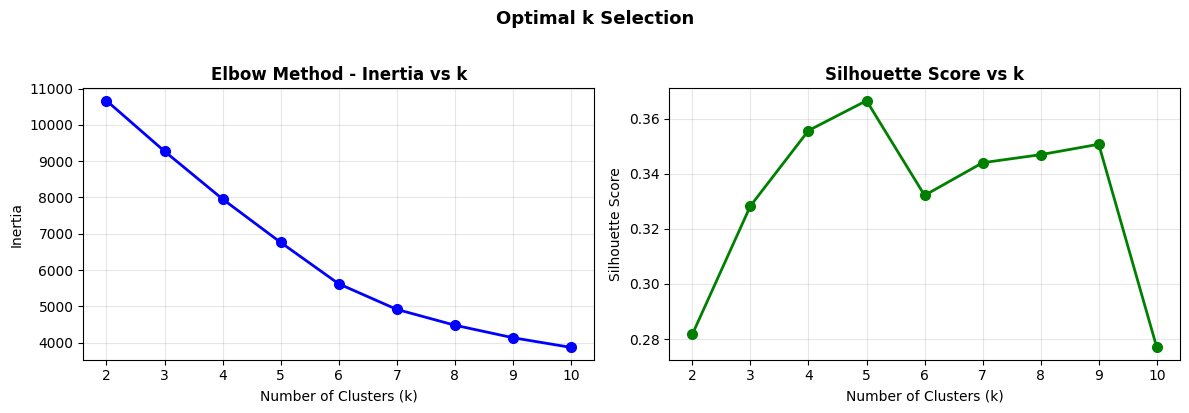


Silhouette Scores by k:
------------------------------
  k=2: 0.2817
  k=3: 0.3283
  k=4: 0.3556
  k=5: 0.3665
  k=6: 0.3321
  k=7: 0.3440
  k=8: 0.3469
  k=9: 0.3507
  k=10: 0.2770


In [ ]:
"""
K-Means Clustering Pipeline - Route Segmentation
=================================================
Assumes the following are already in memory:

    route_features     - route-level summary features from preprocessing
    route_model_errors - per-route model MAPE from forecasting section
    le                 - fitted LabelEncoder from preprocessing
    COLORS             - dict of colors per trend category

K-Means is an unsupervised clustering algorithm that groups routes into k
clusters based on feature similarity. Unlike the forecasting models, K-Means
does not predict a target variable - it discovers natural groupings in the
data. The resulting clusters are interpreted using trend labels and model
error rates computed in the forecasting section.

How K-Means works:
    1. Randomly initialize k cluster centroids
    2. Assign each route to the nearest centroid (Euclidean distance)
    3. Recompute centroids as the mean of all assigned routes
    4. Repeat steps 2-3 until assignments stop changing
    5. The result is k groups of routes that are similar to each other
       and dissimilar from routes in other groups

Because K-Means uses Euclidean distance, all features must be on the same
scale - features are standardized to zero mean and unit variance before
clustering. Trend labels are one-hot encoded rather than ordinally encoded
to avoid imposing a false numeric ordering on unordered categories.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================

# avg_fare excluded - correlated with distance_miles, adds no independent signal
# trend_label excluded - string identifier; one-hot dummies used instead
# lr_mape excluded - Linear Regression is a baseline; only best two models used
CLUSTER_FEATURES = [
    'avg_passengers',
    'passenger_volatility',
    'fare_volatility',
    'distance_miles',
    'distance_band_encoded',
    'xgb_mape',
    'rf_mape',
    'trend_declining',
    'trend_emerging',
    'trend_insufficient_data',
    'trend_stable',
]

RANDOM_STATE = 42

# =============================================================================
# STEP 1: Build clustering dataframe
# =============================================================================

def build_cluster_df(route_features: pd.DataFrame,
                     route_model_errors: pd.DataFrame) -> pd.DataFrame:
    """
    Merge route_features with model error data, drop NaN rows, and return
    a clean dataframe ready for scaling and clustering.

    Rows dropped:
        - Routes with NaN passenger_volatility or fare_volatility
          (single-observation routes where std is undefined)
        - Routes with NaN trend_label
          (routes that fell entirely within shock periods)
        - Routes not present in route_model_errors
          (routes with no test-period activity between 2023-2025)
    """
    cluster_df = route_features.merge(
        route_model_errors[['route', 'xgb_mape', 'rf_mape', 'lr_mape']],
        on='route', how='inner'
    )

    before     = len(cluster_df)
    cluster_df = cluster_df.dropna(subset=CLUSTER_FEATURES + ['trend_label'])
    after      = len(cluster_df)

    print(f"Clustering dataframe: {after} routes "
          f"({before - after} dropped due to NaNs)")

    return cluster_df.reset_index(drop=True)


# =============================================================================
# STEP 2: Scale features
# =============================================================================

def scale_features(cluster_df: pd.DataFrame):
    """
    Standardize all clustering features to zero mean and unit variance.
    Prevents high-magnitude features like avg_passengers or distance_miles
    from dominating the Euclidean distance calculation purely due to scale.
    """
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(cluster_df[CLUSTER_FEATURES])
    return X_scaled, scaler


# =============================================================================
# STEP 3: Elbow method - determine optimal k
# =============================================================================

def plot_elbow(X_scaled, k_range=range(2, 11)):
    """
    Plot inertia and silhouette score across k=2 to k=10 to identify the
    optimal number of clusters empirically.

    Inertia - total squared distance between each point and its centroid.
    Decreases monotonically with k; the elbow marks where improvement slows.

    Silhouette score - measures how similar each point is to its own cluster
    versus the nearest alternative. Range: -1 (wrong cluster) to +1
    (perfectly separated). Higher is better; used as the primary tiebreaker
    when the elbow is ambiguous.

    k=5 was selected: silhouette peaked at 0.3665 and dropped at k=6,
    indicating the sixth cluster fragments a natural grouping rather than
    identifying a genuinely distinct segment.
    """
    inertias    = []
    silhouettes = []

    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7)
    ax1.set_title('Elbow Method - Inertia vs k', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Inertia')
    ax1.grid(alpha=0.3)

    ax2.plot(list(k_range), silhouettes, 'go-', linewidth=2, markersize=7)
    ax2.set_title('Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Silhouette Score')
    ax2.grid(alpha=0.3)

    plt.suptitle('Optimal k Selection', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    # plt.savefig('kmeans_elbow.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nSilhouette Scores by k:")
    print("-" * 30)
    for k, s in zip(k_range, silhouettes):
        print(f"  k={k}: {s:.4f}")

    return inertias, silhouettes


# =============================================================================
# ENTRY POINT
# =============================================================================

cluster_df               = build_cluster_df(route_features, route_model_errors)
X_scaled, cluster_scaler = scale_features(cluster_df)
inertias, silhouettes    = plot_elbow(X_scaled)

In [221]:
K = 5   # update this after examining the elbow plot

# Step 4 - Fit final model
km_model = fit_kmeans(X_scaled, K)


K-Means fitted with k=5.
Inertia: 6,762.5
Silhouette Score: 0.3665


In [222]:
# Step 5 - Interpret clusters
cluster_df = interpret_clusters(cluster_df, km_model.labels_)


Cluster Summary:
         n_routes  avg_passengers  avg_distance  passenger_vol  fare_vol  xgb_mape  rf_mape
cluster                                                                                    
0             725          625.56       1133.76         180.90     32.00     13.19    11.44
1              98          630.11        658.82         187.16     32.01     13.64    11.48
2              54         5072.23       1140.61        1319.82     26.78     12.51     8.22
3             224          503.40       1027.30         130.53     30.71     13.71    12.55
4              64          204.37       1068.75          60.96     28.78     12.87     9.58

Trend Label Composition by Cluster:
-------------------------------------------------------
         declining  emerging  insufficient_data  stable  declining_pct  emerging_pct  insufficient_data_pct  stable_pct
cluster                                                                                                                
0    

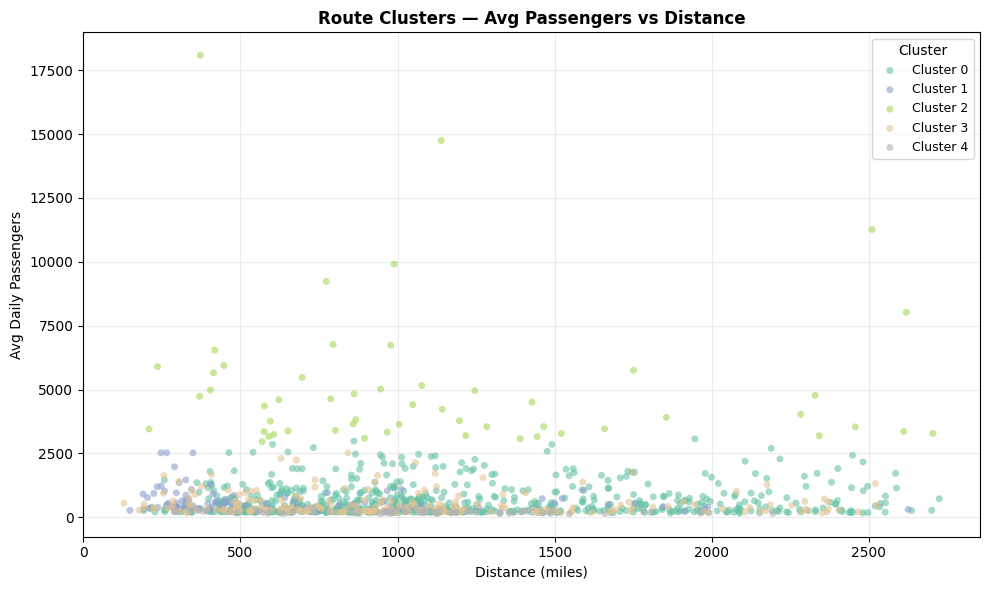

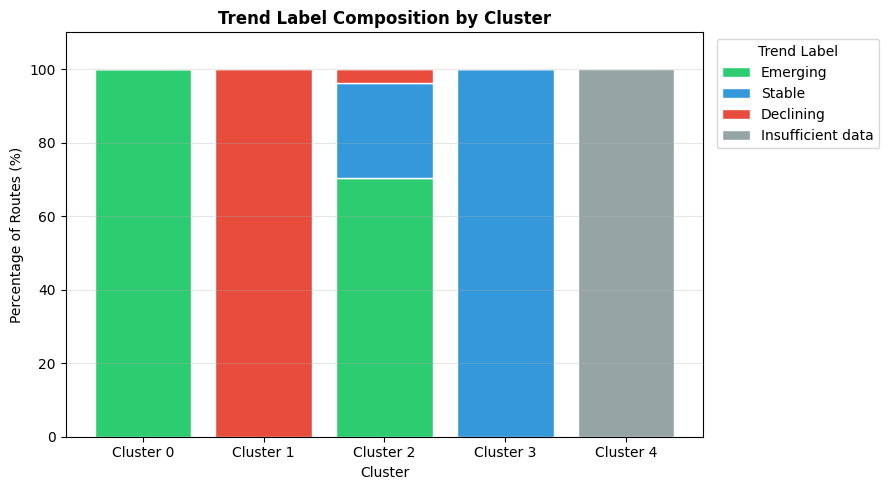

In [223]:
# Step 6 - Visualize
plot_clusters(cluster_df, K)

# Generating Recommendations

In [224]:
## Viewing The State of `cluster_df`

print(cluster_df.columns.tolist())
print(cluster_df.shape)
print(cluster_df['cluster'].value_counts().sort_index())

['route', 'avg_passengers', 'passenger_volatility', 'avg_fare', 'fare_volatility', 'distance_miles', 'distance_band_encoded', 'trend_label', 'trend_declining', 'trend_emerging', 'trend_insufficient_data', 'trend_stable', 'xgb_mape', 'rf_mape', 'lr_mape', 'cluster']
(1165, 16)
cluster
0    725
1     98
2     54
3    224
4     64
Name: count, dtype: int64


RECOMMENDATION 1 - Emerging Routes: Invest / Grow Selectively
These routes show statistically significant passenger growth.
Ranked by average daily passengers (highest opportunity first).

                                          route  avg_passengers  distance_miles  passenger_volatility  rf_mape
1               Atlanta, GA <-> Los Angeles, CA         3071.30            1946                706.14     6.19
2              Orlando, FL <-> Philadelphia, PA         2983.75             861                671.50     8.78
3                 Denver, CO <-> Washington, DC         2854.93            1491                703.04     7.02
4                    Denver, CO <-> Phoenix, AZ         2854.25             602                603.34     8.58
5         Atlanta, GA <-> Dallas/Fort Worth, TX         2730.01             732                660.57     5.80
6             New York City, NY <-> Phoenix, AZ         2696.56            2189                704.34     7.27
7   Dallas/Fort Worth, TX <-> San 

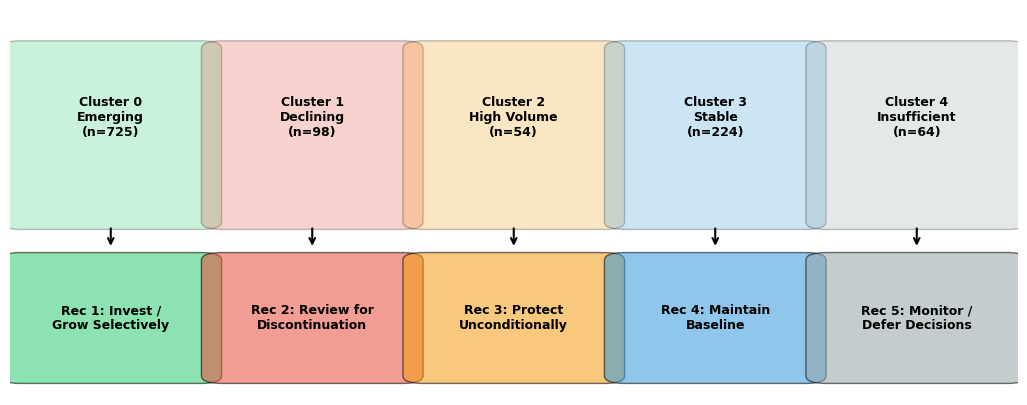

In [ ]:
"""
Route-Level Actionable Insights - Five Recommendations
======================================================
Continuation script - assumes cluster_df is already in memory
from the K-Means clustering section.

Recommendation mapping:
    Rec 1 -> Cluster 0 - Emerging routes         : Invest / Grow Selectively
    Rec 2 -> Cluster 1 - Declining routes        : Review for Discontinuation
    Rec 3 -> Cluster 2 - High volume routes      : Protect Unconditionally
    Rec 4 -> Cluster 3 - Stable routes           : Maintain Baseline
    Rec 5 -> Cluster 4 - Insufficient data routes: Monitor / Defer Decisions
"""

import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

# =============================================================================
# REC 1: Cluster 0 - Emerging routes: Invest / Grow Selectively
# =============================================================================
# Low-to-mid volume routes with a statistically significant upward passenger
# trend. Ranked by avg_passengers descending - larger emerging routes
# represent the most immediate capacity investment opportunity.

rec1 = (
    cluster_df[cluster_df['cluster'] == 0]
    [['route', 'avg_passengers', 'distance_miles',
  'passenger_volatility', 'rf_mape']]
    .sort_values('avg_passengers', ascending=False)
    .reset_index(drop=True)
)
rec1.index += 1

print("RECOMMENDATION 1 - Emerging Routes: Invest / Grow Selectively")
print("=" * 70)
print("These routes show statistically significant passenger growth.")
print("Ranked by average daily passengers (highest opportunity first).\n")
print(rec1.head(20).to_string())
print(f"\nTotal emerging routes: {len(rec1)}")

# =============================================================================
# REC 2: Cluster 1 - Declining routes: Review for Discontinuation
# =============================================================================
# Routes with a statistically significant downward passenger trend.
# Ranked by avg_passengers ascending - smallest declining routes are
# the lowest-risk discontinuation candidates.

rec2 = (
    cluster_df[cluster_df['cluster'] == 1]
    [['route', 'avg_passengers', 'distance_miles',
  'passenger_volatility', 'rf_mape']]
    .sort_values('avg_passengers', ascending=True)
    .reset_index(drop=True)
)
rec2.index += 1

print("\n\nRECOMMENDATION 2 - Declining Routes: Review for Discontinuation")
print("=" * 70)
print("These routes show statistically significant passenger decline.")
print("Ranked by average daily passengers (lowest volume = highest")
print("discontinuation priority).\n")
print(rec2.head(20).to_string())
print(f"\nTotal declining routes: {len(rec2)}")

# =============================================================================
# REC 3: Cluster 2 - High volume routes: Protect Unconditionally
# =============================================================================
# The busiest routes in the network. Split by trend label to distinguish
# expansion candidates (emerging) from maintenance routes (stable) and
# the two anomalous declining corridors requiring individual strategic review.

rec3 = (
    cluster_df[cluster_df['cluster'] == 2]
    [['route', 'avg_passengers', 'distance_miles',
  'trend_label', 'rf_mape']]
    .sort_values(['trend_label', 'avg_passengers'],
                 ascending=[True, False])
    .reset_index(drop=True)
)
rec3.index += 1

print("\n\nRECOMMENDATION 3 - High-Volume Corridors: Protect Unconditionally")
print("=" * 70)
print("These are the busiest routes in the domestic network.")
print("Emerging subset: expand capacity.")
print("Stable subset:   maintain current capacity.")
print("Declining subset: defend strategically - do not cut.\n")
print(rec3.to_string())

declining_hv = rec3[rec3['trend_label'] == 'declining']
print(f"\nHigh-volume declining routes requiring individual review:")
print(declining_hv.to_string())

# =============================================================================
# REC 4: Cluster 3 - Stable routes: Maintain Baseline
# =============================================================================
# Routes with no statistically significant trend - demand is flat but
# consistent. These form the reliable revenue backbone of the network.
# Ranked by avg_passengers descending.

rec4 = (
    cluster_df[cluster_df['cluster'] == 3]
    [['route', 'avg_passengers', 'distance_miles',
  'passenger_volatility', 'rf_mape']]
    .sort_values('avg_passengers', ascending=False)
    .reset_index(drop=True)
)
rec4.index += 1

print("\n\nRECOMMENDATION 4 - Stable Routes: Maintain as Network Backbone")
print("=" * 70)
print("These routes show no significant trend - demand is flat but reliable.")
print("Ranked by average daily passengers.\n")
print(rec4.head(20).to_string())
print(f"\nTotal stable routes: {len(rec4)}")

# =============================================================================
# REC 5: Cluster 4 - Insufficient data routes: Monitor / Defer Decisions
# =============================================================================
# Routes that lack the minimum quarterly observations required to establish
# a reliable trend classification. Their strategic direction cannot yet be
# determined. Airlines should continue monitoring these routes and defer
# major capacity or investment decisions until sufficient data accumulates.

rec5 = (
    cluster_df[cluster_df['cluster'] == 4]
    [['route', 'avg_passengers', 'distance_miles',
  'passenger_volatility', 'rf_mape']]
    .sort_values('avg_passengers', ascending=False)
    .reset_index(drop=True)
)
rec5.index += 1

print("\n\nRECOMMENDATION 5 - Insufficient Data Routes: Monitor & Defer")
print("=" * 70)
print("These routes lack sufficient quarterly observations to establish")
print("a reliable trend. Defer major capacity decisions until enough")
print("data accumulates to support trend classification.\n")
print(rec5.to_string())
print(f"\nTotal insufficient data routes: {len(rec5)}")

# =============================================================================
# SUMMARY VISUALIZATION - Recommendation framework by cluster
# =============================================================================

cluster_labels = {
    0: 'Cluster 0\nEmerging\n(n=725)',
    1: 'Cluster 1\nDeclining\n(n=98)',
    2: 'Cluster 2\nHigh Volume\n(n=54)',
    3: 'Cluster 3\nStable\n(n=224)',
    4: 'Cluster 4\nInsufficient\n(n=64)',
}

recommendations = {
    0: 'Rec 1: Invest /\nGrow Selectively',
    1: 'Rec 2: Review for\nDiscontinuation',
    2: 'Rec 3: Protect\nUnconditionally',
    3: 'Rec 4: Maintain\nBaseline',
    4: 'Rec 5: Monitor /\nDefer Decisions',
}

rec_colors = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#f39c12',
    3: '#3498db',
    4: '#95a5a6',
}

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis('off')

for i, cluster_id in enumerate(range(5)):
    ax.add_patch(mpatches.FancyBboxPatch(
        (i * 0.2 + 0.01, 0.45), 0.18, 0.45,
        boxstyle="round,pad=0.02",
        facecolor=rec_colors[cluster_id],
        alpha=0.25, transform=ax.transAxes
    ))
    ax.text(i * 0.2 + 0.10, 0.72,
            cluster_labels[cluster_id],
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            transform=ax.transAxes)

    ax.annotate('', xy=(i * 0.2 + 0.10, 0.38),
                xytext=(i * 0.2 + 0.10, 0.44),
                xycoords='axes fraction',
                textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

    ax.add_patch(mpatches.FancyBboxPatch(
        (i * 0.2 + 0.01, 0.05), 0.18, 0.30,
        boxstyle="round,pad=0.02",
        facecolor=rec_colors[cluster_id],
        alpha=0.55, transform=ax.transAxes
    ))
    ax.text(i * 0.2 + 0.10, 0.20,
            recommendations[cluster_id],
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            transform=ax.transAxes)

# =============================================================================
# EXPORT TO CSV
# =============================================================================

# rec1.to_csv('rec1_emerging_invest.csv')
# rec2.to_csv('rec2_declining_discontinue.csv')
# rec3.to_csv('rec3_highvolume_protect.csv')
# rec4.to_csv('rec4_stable_maintain.csv')
# rec5.to_csv('rec5_insufficient_monitor.csv')

# print("\nAll recommendation tables exported to CSV.")
# print("Rec 1-5: Cluster-based (one per cluster, Clusters 0-4)")